## two batch


Batch: C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-04
Found 237 files

Batch: C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-05
Found 274 files

Total files loaded: 511

Available keys:
  snail_frequency
  I
  Q
  Magnitude
Loading (1/511): 19-06-51_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (2/511): 19-08-07_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (3/511): 19-09-22_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (4/511): 19-10-37_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (5/511): 19-11-50_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (6/511): 19-13-05_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (7/511): 19-14-19_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (8/511): 19-15-33_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (9/511): 19-16-48_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (10/511): 19-18-03_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (11/511): 19-19-17_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (12/511): 1

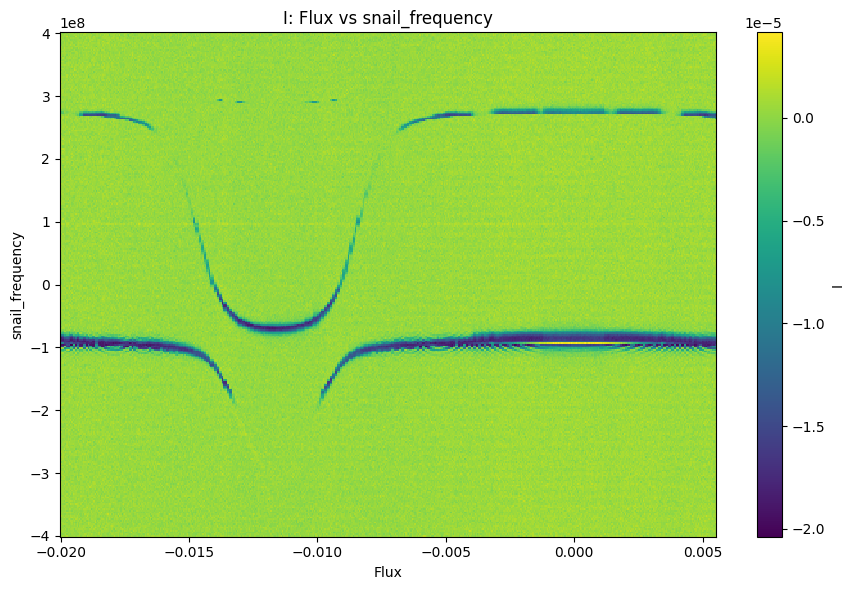

In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================

# --- Define all batches here ---
batches = [
    {
        "folder": r"C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-04",
        "time": ((19,6), (23, 59)),
        "flux": np.linspace(start=-20e-3, stop=20e-3, num=801)[0:237],
    },
    {
        "folder": r"C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-05",
        "time": ((0, 0), (6, 0)),
        "flux": np.linspace(start=-20e-3, stop=20e-3, num=801)[237:237+274],
    },
]

file_key = "SnailSpec_twotone_sideq_versus_flu"

plot_data = "I"          # "I", "Q", or "MAG"
y_key = None             # None -> automatically choose first dataset
show_individual_plots = False

x_label = "Flux"

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = filename.split("-")
        return (int(parts[0]), int(parts[1]))
    except:
        return (-1, -1)


def get_filtered_files(folder, start_time, end_time):

    selected = []

    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return selected

    for filename in os.listdir(folder):

        if not filename.endswith(".hdf5"):
            continue

        if file_key not in filename:
            continue

        t = extract_time(filename)

        if start_time <= t <= end_time:
            selected.append(os.path.join(folder, filename))

    selected.sort()

    return selected


# ==========================================================
# COLLECT FILES FROM ALL BATCHES
# ==========================================================

grouped_filenames = []
x_values = []

for batch in batches:

    folder = batch["folder"]
    start_time, end_time = batch["time"]

    files = get_filtered_files(folder, start_time, end_time)

    print(f"\nBatch: {folder}")
    print(f"Found {len(files)} files")

    if len(files) != len(batch["flux"]):
        print(
            f"WARNING: {len(files)} files but {len(batch['flux'])} flux values."
        )

    n = min(len(files), len(batch["flux"]))

    grouped_filenames.extend(files[:n])
    x_values.extend(batch["flux"][:n])

if len(grouped_filenames) == 0:
    raise ValueError("No files found.")

x_values = np.array(x_values)

print(f"\nTotal files loaded: {len(grouped_filenames)}")

# ==========================================================
# DISPLAY AVAILABLE KEYS
# ==========================================================

with h5py.File(grouped_filenames[0], "r") as f:

    print("\nAvailable keys:")

    for k in f.keys():
        print(" ", k)

# ==========================================================
# EXTRACT DATA
# ==========================================================

sweep_axis = []
data_2d = []

for i, filename in enumerate(grouped_filenames):

    print(f"Loading ({i+1}/{len(grouped_filenames)}): {os.path.basename(filename)}")

    with h5py.File(filename, "r") as f:

        # ----------------------------------
        # Sweep axis
        # ----------------------------------

        if y_key is None:
            key = list(f.keys())[0]
        else:
            key = y_key

        y_values = np.array(f[key][()])

        # ----------------------------------
        # Channels
        # ----------------------------------

        I_values = np.mean(f["I"][()], axis=0)
        I_values -= np.mean(I_values)

        Q_values = np.mean(f["Q"][()], axis=0)
        Q_values -= np.mean(Q_values)

        MAG_values = np.mean(f["Magnitude"][()], axis=0)
        MAG_values -= np.mean(MAG_values)

        channel_dict = {
            "I": I_values,
            "Q": Q_values,
            "MAG": MAG_values,
        }

        selected_data = channel_dict[plot_data]

        sweep_axis.append(y_values)
        data_2d.append(selected_data)

        # ----------------------------------
        # Optional individual plots
        # ----------------------------------

        if show_individual_plots:

            plt.figure(figsize=(8,4))

            plt.plot(y_values, selected_data)

            plt.xlabel(key)
            plt.ylabel(plot_data)
            plt.title(f"{plot_data}, {x_label} = {x_values[i]:.6f}")

            plt.grid(True)
            plt.tight_layout()
            plt.show()

# ==========================================================
# CONVERT TO ARRAYS
# ==========================================================

sweep_axis = np.array(sweep_axis)
data_2d = np.array(data_2d)

print("Data shape:", data_2d.shape)

# ==========================================================
# 2D COLORMAP
# ==========================================================

plt.figure(figsize=(9,6))

plt.pcolormesh(
    x_values,
    sweep_axis[0],
    data_2d.T,
    shading="auto",
    cmap="viridis",
)

plt.xlabel(x_label)
plt.ylabel(key)
plt.title(f"{plot_data}: {x_label} vs {key}")

plt.colorbar(label=plot_data)

plt.tight_layout()
plt.show()

In [2]:
# ==========================================================
# SAVE SETTINGS
# ==========================================================

save_npz = True
save_name = "SnailSpec_twotone_sideq_versus_flux_IQ.npz"

# ==========================================================
# EXTRACT DATA
# ==========================================================

sweep_axis = []

I_2d = []
Q_2d = []
MAG_2d = []

data_2d = []

for i, filename in enumerate(grouped_filenames):

    print(f"Loading ({i+1}/{len(grouped_filenames)}): {os.path.basename(filename)}")

    with h5py.File(filename, "r") as f:

        # ----------------------------------
        # Sweep axis
        # ----------------------------------

        if y_key is None:
            key = list(f.keys())[0]
        else:
            key = y_key

        y_values = np.array(f[key][()])

        # ----------------------------------
        # Channels
        # ----------------------------------

        I_values = np.mean(f["I"][()], axis=0)
        Q_values = np.mean(f["Q"][()], axis=0)
        MAG_values = np.mean(f["Magnitude"][()], axis=0)

        # Optional background subtraction
        I_values = I_values - np.mean(I_values)
        Q_values = Q_values - np.mean(Q_values)
        MAG_values = MAG_values - np.mean(MAG_values)

        I_2d.append(I_values)
        Q_2d.append(Q_values)
        MAG_2d.append(MAG_values)

        channel_dict = {
            "I": I_values,
            "Q": Q_values,
            "MAG": MAG_values,
        }

        selected_data = channel_dict[plot_data]

        sweep_axis.append(y_values)
        data_2d.append(selected_data)

        # ----------------------------------
        # Optional individual plots
        # ----------------------------------

        if show_individual_plots:

            plt.figure(figsize=(8,4))
            plt.plot(y_values, selected_data)

            plt.xlabel(key)
            plt.ylabel(plot_data)
            plt.title(f"{plot_data}, {x_label} = {x_values[i]:.6f}")

            plt.grid(True)
            plt.tight_layout()
            plt.show()

# ==========================================================
# CONVERT TO ARRAYS
# ==========================================================

sweep_axis = np.array(sweep_axis)

I_2d = np.array(I_2d)
Q_2d = np.array(Q_2d)
MAG_2d = np.array(MAG_2d)

data_2d = np.array(data_2d)

print("I shape:", I_2d.shape)
print("Q shape:", Q_2d.shape)
print("MAG shape:", MAG_2d.shape)
print("Data shape:", data_2d.shape)

# ==========================================================
# SAVE IQ DATA
# ==========================================================

if save_npz:

    save_path = os.path.join(
        os.path.dirname(grouped_filenames[0]),
        save_name,
    )

    np.savez_compressed(
        save_path,
        x_values=x_values,
        sweep_axis=sweep_axis,
        y_values=sweep_axis[0],
        I=I_2d,
        Q=Q_2d,
        MAG=MAG_2d,
        selected_data=data_2d,
        plot_data=plot_data,
        x_label=x_label,
        y_key=key,
        filenames=np.array(grouped_filenames),
    )

    print(f"Saved IQ data to:\n{save_path}")

Loading (1/511): 19-06-51_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (2/511): 19-08-07_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (3/511): 19-09-22_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (4/511): 19-10-37_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (5/511): 19-11-50_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (6/511): 19-13-05_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (7/511): 19-14-19_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (8/511): 19-15-33_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (9/511): 19-16-48_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (10/511): 19-18-03_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (11/511): 19-19-17_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (12/511): 19-20-32_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (13/511): 19-21-46_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (14/511): 19-23-01_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (15/511): 19-24-15_SnailSpec_twotone_sideq_versus

Available keys:
  x_values
  sweep_axis
  y_values
  I
  Q
  MAG
  selected_data
  plot_data
  x_label
  y_key
  filenames
x shape: (511,)
y shape: (301,)
data shape: (511, 301)


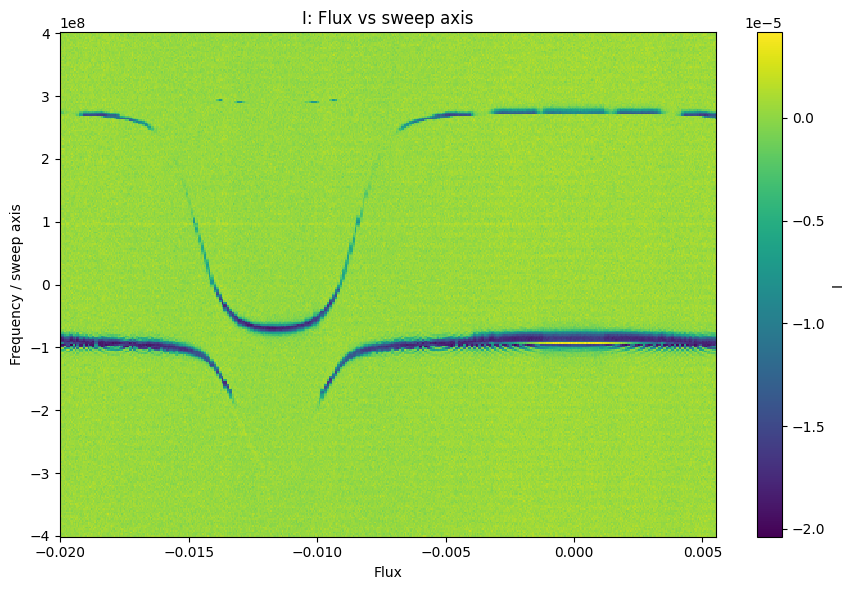

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================

npz_path = r"C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-04/SnailSpec_twotone_sideq_versus_flux_IQ.npz"

plot_data = "I"   # "I", "Q", or "MAG"

# Optional plot limits
vmin = None
vmax = None

# ==========================================================
# LOAD NPZ
# ==========================================================

data = np.load(npz_path, allow_pickle=True)

print("Available keys:")
for k in data.keys():
    print(" ", k)

x_values = data["x_values"]

# Use y_values if available, otherwise sweep_axis[0]
if "y_values" in data.keys():
    y_values = data["y_values"]
else:
    y_values = data["sweep_axis"][0]

I_2d = data["I"]
Q_2d = data["Q"]

if "MAG" in data.keys():
    MAG_2d = data["MAG"]
else:
    MAG_2d = np.sqrt(I_2d**2 + Q_2d**2)

channel_dict = {
    "I": I_2d,
    "Q": Q_2d,
    "MAG": MAG_2d,
}

data_2d = channel_dict[plot_data]

print("x shape:", x_values.shape)
print("y shape:", y_values.shape)
print("data shape:", data_2d.shape)

# ==========================================================
# PLOT
# ==========================================================

plt.figure(figsize=(9, 6))

plt.pcolormesh(
    x_values,
    y_values,
    data_2d.T,
    shading="auto",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

plt.xlabel("Flux")
plt.ylabel("Frequency / sweep axis")
plt.title(f"{plot_data}: Flux vs sweep axis")

plt.colorbar(label=plot_data)

plt.tight_layout()
plt.show()

x shape: (511,)
y shape: (301,)
data shape: (511, 301)
min_y_values shape: (511,)
min_values shape: (511,)
Saved min trace to:
C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-04/SnailSpec_twotone_sideq_versus_flux_IQ_I_min_trace.npz


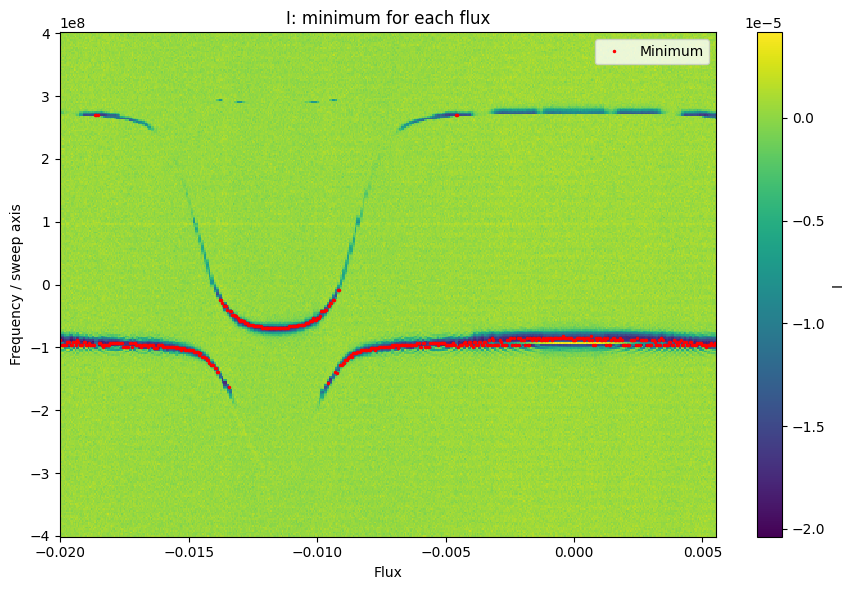

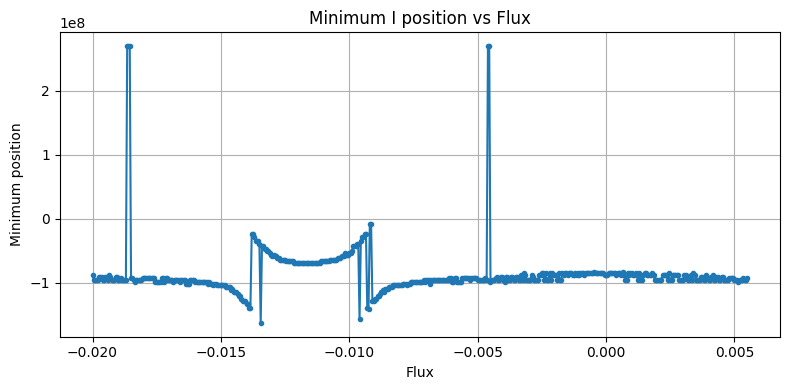

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================

npz_path = r"C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-04/SnailSpec_twotone_sideq_versus_flux_IQ.npz"

plot_data = "I"   # "I", "Q", or "MAG"

save_min = True
save_name = "SnailSpec_twotone_sideq_versus_flux_min_trace.npz"

# ==========================================================
# LOAD NPZ
# ==========================================================

data = np.load(npz_path, allow_pickle=True)

x_values = data["x_values"]

if "y_values" in data.keys():
    y_values = data["y_values"]
else:
    y_values = data["sweep_axis"][0]

I_2d = data["I"]
Q_2d = data["Q"]

if "MAG" in data.keys():
    MAG_2d = data["MAG"]
else:
    MAG_2d = np.sqrt(I_2d**2 + Q_2d**2)

channel_dict = {
    "I": I_2d,
    "Q": Q_2d,
    "MAG": MAG_2d,
}

data_2d = channel_dict[plot_data]

print("x shape:", x_values.shape)
print("y shape:", y_values.shape)
print("data shape:", data_2d.shape)

# ==========================================================
# GET MINIMUM FOR EACH FLUX
# ==========================================================

# data_2d shape should be: (num_flux, num_sweep_points)
min_indices = np.argmin(data_2d, axis=1)

min_y_values = y_values[min_indices]
min_values = data_2d[np.arange(len(x_values)), min_indices]

print("min_y_values shape:", min_y_values.shape)
print("min_values shape:", min_values.shape)

# ==========================================================
# SAVE MINIMUM TRACE
# ==========================================================

if save_min:
    save_path = npz_path.replace(".npz", "_" + plot_data + "_min_trace.npz")

    np.savez_compressed(
        save_path,
        x_values=x_values,
        min_y_values=min_y_values,
        min_values=min_values,
        min_indices=min_indices,
        plot_data=plot_data,
    )

    print(f"Saved min trace to:\n{save_path}")

# ==========================================================
# PLOT 2D DATA WITH MIN TRACE
# ==========================================================

plt.figure(figsize=(9, 6))

plt.pcolormesh(
    x_values,
    y_values,
    data_2d.T,
    shading="auto",
    cmap="viridis",
)

plt.plot(
    x_values,
    min_y_values,
    "r.",
    markersize=3,
    label="Minimum",
)

plt.xlabel("Flux")
plt.ylabel("Frequency / sweep axis")
plt.title(f"{plot_data}: minimum for each flux")

plt.colorbar(label=plot_data)
plt.legend()

plt.tight_layout()
plt.show()

# ==========================================================
# PLOT MINIMUM FREQUENCY VS FLUX
# ==========================================================

plt.figure(figsize=(8, 4))

plt.plot(x_values, min_y_values, "o-", markersize=3)

plt.xlabel("Flux")
plt.ylabel("Minimum position")
plt.title(f"Minimum {plot_data} position vs Flux")

plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
# ==========================================================
# SELECT FLUX RANGE AND DISCARD OUTLIERS
# ==========================================================

# Flux range in A
flux_min = -15e-3
flux_max = -8e-3

range_mask = (x_values >= flux_min) & (x_values <= flux_max)

x_sel = x_values[range_mask]
min_y_sel = min_y_values[range_mask]
min_val_sel = min_values[range_mask]

# ----------------------------------------------------------
# Outlier rejection
# A point is discarded if it is far from BOTH neighbors.
# ----------------------------------------------------------

# Manual threshold in sweep-axis units.
# Example: if y_values is in GHz, 0.005 means 5 MHz.
jump_threshold = 0.005

good_mask = np.ones_like(min_y_sel, dtype=bool)

for i in range(1, len(min_y_sel) - 1):

    jump_left = abs(min_y_sel[i] - min_y_sel[i - 1])
    jump_right = abs(min_y_sel[i] - min_y_sel[i + 1])

    if jump_left > jump_threshold and jump_right > jump_threshold:
        good_mask[i] = False

x_clean = x_sel[good_mask]
min_y_clean = min_y_sel[good_mask]
min_val_clean = min_val_sel[good_mask]

print(f"Selected points: {len(x_sel)}")
print(f"Kept points: {len(x_clean)}")
print(f"Discarded points: {len(x_sel) - len(x_clean)}")

Selected points: 141
Kept points: 120
Discarded points: 21


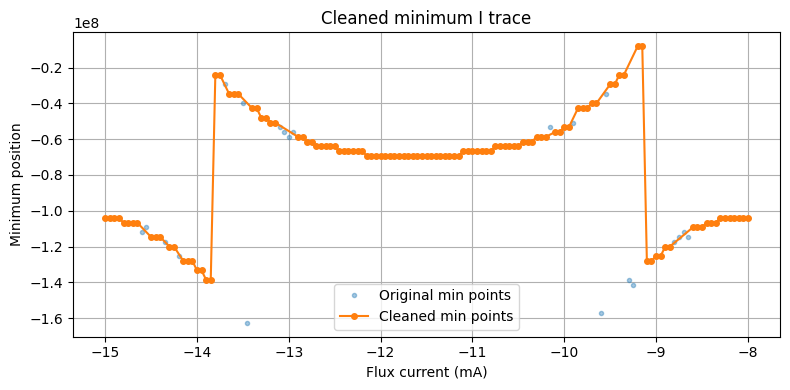

In [10]:
# ==========================================================
# PLOT CLEANED MINIMUM TRACE
# ==========================================================

plt.figure(figsize=(8, 4))

plt.plot(
    x_sel * 1e3,
    min_y_sel,
    "o",
    markersize=3,
    alpha=0.4,
    label="Original min points",
)

plt.plot(
    x_clean * 1e3,
    min_y_clean,
    "o-",
    markersize=4,
    label="Cleaned min points",
)

plt.xlabel("Flux current (mA)")
plt.ylabel("Minimum position")
plt.title(f"Cleaned minimum {plot_data} trace")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# ==========================================================
# PRINT SEPARATE ARRAYS: current and cav_if
# ==========================================================

current = x_clean      # in A
cav_if = min_y_clean

print("current = [")
print(", ".join(f"{x:.9g}" for x in current))
print("]")

print("\ncav_if = [")
print(", ".join(f"{y:.9g}" for y in cav_if))
print("]")

current = [
-0.015, -0.01495, -0.0149, -0.01485, -0.0148, -0.01475, -0.0147, -0.01465, -0.0145, -0.01445, -0.0144, -0.0143, -0.01425, -0.01415, -0.0141, -0.01405, -0.014, -0.01395, -0.0139, -0.01385, -0.0138, -0.01375, -0.01365, -0.0136, -0.01355, -0.0134, -0.01335, -0.0133, -0.01325, -0.0132, -0.01315, -0.0129, -0.01285, -0.0128, -0.01275, -0.0127, -0.01265, -0.0126, -0.01255, -0.0125, -0.01245, -0.0124, -0.01235, -0.0123, -0.01225, -0.0122, -0.01215, -0.0121, -0.01205, -0.012, -0.01195, -0.0119, -0.01185, -0.0118, -0.01175, -0.0117, -0.01165, -0.0116, -0.01155, -0.0115, -0.01145, -0.0114, -0.01135, -0.0113, -0.01125, -0.0112, -0.01115, -0.0111, -0.01105, -0.011, -0.01095, -0.0109, -0.01085, -0.0108, -0.01075, -0.0107, -0.01065, -0.0106, -0.01055, -0.0105, -0.01045, -0.0104, -0.01035, -0.0103, -0.01025, -0.0102, -0.0101, -0.01005, -0.01, -0.00995, -0.00985, -0.0098, -0.00975, -0.0097, -0.00965, -0.0095, -0.00945, -0.0094, -0.00935, -0.0092, -0.00915, -0.0091, -0.00905, -0.009, -0.0089


C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-03
Found 248 files

C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-04
Found 263 files

Total files: 511

Available keys:
  cavity_frequency
  I
  Q
  Magnitude
Loading (1/511): 18-10-59_CavitySpec_versus_flux.hdf5
Loading (2/511): 18-12-25_CavitySpec_versus_flux.hdf5
Loading (3/511): 18-13-49_CavitySpec_versus_flux.hdf5
Loading (4/511): 18-15-14_CavitySpec_versus_flux.hdf5
Loading (5/511): 18-16-38_CavitySpec_versus_flux.hdf5
Loading (6/511): 18-18-03_CavitySpec_versus_flux.hdf5
Loading (7/511): 18-19-28_CavitySpec_versus_flux.hdf5
Loading (8/511): 18-20-53_CavitySpec_versus_flux.hdf5
Loading (9/511): 18-22-18_CavitySpec_versus_flux.hdf5
Loading (10/511): 18-23-42_CavitySpec_versus_flux.hdf5
Loading (11/511): 18-25-07_CavitySpec_versus_flux.hdf5
Loading (12/511): 18-26-32_CavitySpec_versus_flux.hdf5
Loading (13/511): 18-27-56_CavitySpec_versus_flux.hdf5
Loading (14/511): 18-29-21_CavitySpec_versus_flux.hdf5
Loading (15/511):

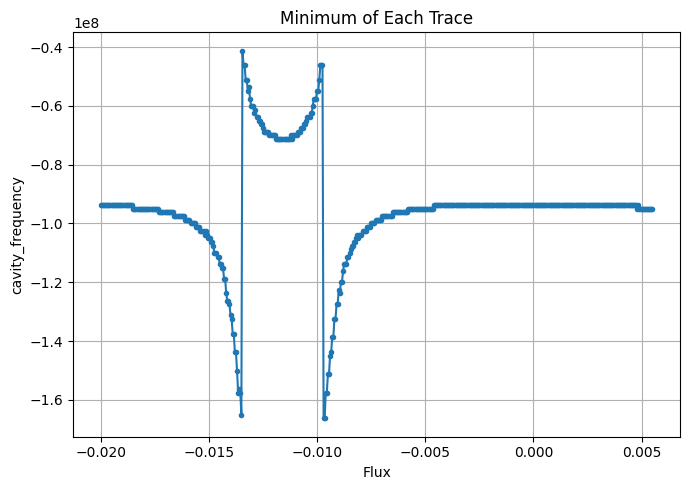

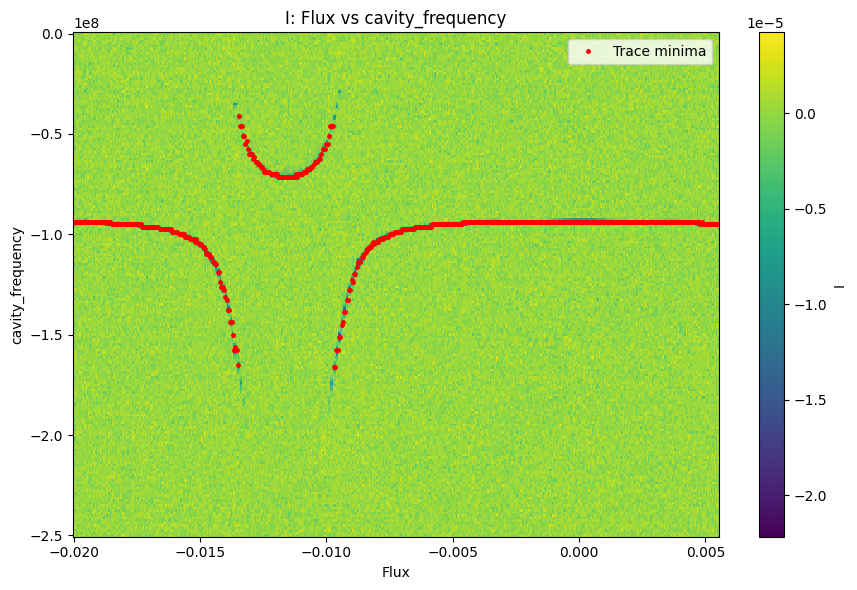


Saved minima to trace_minima.npz


In [2]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================

# --- Define all batches here ---
batches = [
    {
        "folder": r"C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-03",
        "time": ((18, 10), (23, 59)),
        "flux": np.linspace(start=-20e-3, stop=20e-3, num=801)[0:248],
    },
    {
        "folder": r"C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-04",
        "time": ((0, 0), (14, 0)),
        "flux": np.linspace(start=-20e-3, stop=20e-3, num=801)[248:248+263],
    },
]

file_key = "CavitySpec_versus_flux"

plot_data = "I"      # "I", "Q", or "MAG"
y_key = None         # None -> automatically choose first dataset
show_individual_plots = False

x_label = "Flux"

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = filename.split("-")
        return (int(parts[0]), int(parts[1]))
    except:
        return (-1, -1)


def get_filtered_files(folder, start_time, end_time):

    selected = []

    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return selected

    for filename in os.listdir(folder):

        if not filename.endswith(".hdf5"):
            continue

        if file_key not in filename:
            continue

        t = extract_time(filename)

        if start_time <= t <= end_time:
            selected.append(os.path.join(folder, filename))

    selected.sort()

    return selected


# ==========================================================
# COLLECT FILES FROM ALL BATCHES
# ==========================================================

grouped_filenames = []
x_values = []

for batch in batches:

    files = get_filtered_files(
        batch["folder"],
        batch["time"][0],
        batch["time"][1],
    )

    print(f"\n{batch['folder']}")
    print(f"Found {len(files)} files")

    if len(files) != len(batch["flux"]):
        print(
            f"WARNING: {len(files)} files but {len(batch['flux'])} flux values."
        )

    n = min(len(files), len(batch["flux"]))

    grouped_filenames.extend(files[:n])
    x_values.extend(batch["flux"][:n])

if len(grouped_filenames) == 0:
    raise ValueError("No files found!")

x_values = np.array(x_values)

print(f"\nTotal files: {len(grouped_filenames)}")

# ==========================================================
# DISPLAY AVAILABLE KEYS
# ==========================================================

with h5py.File(grouped_filenames[0], "r") as f:

    print("\nAvailable keys:")

    for k in f.keys():
        print(" ", k)

# ==========================================================
# EXTRACT DATA
# ==========================================================

sweep_axis = []
data_2d = []

for i, filename in enumerate(grouped_filenames):

    print(f"Loading ({i+1}/{len(grouped_filenames)}): {os.path.basename(filename)}")

    with h5py.File(filename, "r") as f:

        # ----------------------------------
        # Sweep axis
        # ----------------------------------

        if y_key is None:
            key = list(f.keys())[0]
        else:
            key = y_key

        y_values = np.array(f[key][()])

        # ----------------------------------
        # Channels
        # ----------------------------------

        I_values = np.mean(f["I"][()], axis=0)
        I_values -= np.mean(I_values)

        Q_values = np.mean(f["Q"][()], axis=0)
        Q_values -= np.mean(Q_values)

        MAG_values = np.mean(f["Magnitude"][()], axis=0)
        MAG_values -= np.mean(MAG_values)

        channel_dict = {
            "I": I_values,
            "Q": Q_values,
            "MAG": MAG_values,
        }

        selected_data = channel_dict[plot_data]

        sweep_axis.append(y_values)
        data_2d.append(selected_data)

        if show_individual_plots:

            plt.figure(figsize=(8,4))
            plt.plot(y_values, selected_data)

            plt.xlabel(key)
            plt.ylabel(plot_data)
            plt.title(f"{plot_data}, Flux = {x_values[i]:.6f}")

            plt.grid(True)
            plt.tight_layout()
            plt.show()

# ==========================================================
# CONVERT TO ARRAYS
# ==========================================================

sweep_axis = np.array(sweep_axis)
data_2d = np.array(data_2d)

print("\n2D data shape:", data_2d.shape)

# ==========================================================
# FIND MINIMUM OF EACH TRACE
# ==========================================================

min_indices = np.argmin(data_2d, axis=1)

# If all traces have the same sweep axis:
min_freq = sweep_axis[0][min_indices]

# If sweep axis changes between files, use instead:
# min_freq = sweep_axis[np.arange(len(sweep_axis)), min_indices]

min_value = data_2d[np.arange(len(data_2d)), min_indices]

print("\nFlux\t\tMinimum Frequency\tMinimum Value")
print("-"*60)

for flux, freq, val in zip(x_values, min_freq, min_value):
    print(f"{flux:.6f}\t{freq:.6f}\t{val:.6f}")

# ==========================================================
# PLOT MINIMUM FREQUENCY VS FLUX
# ==========================================================

plt.figure(figsize=(7,5))

plt.plot(x_values, min_freq, ".-")

plt.xlabel(x_label)
plt.ylabel(key)
plt.title("Minimum of Each Trace")

plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================================
# 2D COLORMAP
# ==========================================================

plt.figure(figsize=(9,6))

plt.pcolormesh(
    x_values,
    sweep_axis[0],
    data_2d.T,
    shading="auto",
    cmap="viridis",
)

# Overlay minima
plt.plot(
    x_values,
    min_freq,
    "r.",
    markersize=5,
    label="Trace minima",
)

plt.xlabel(x_label)
plt.ylabel(key)
plt.title(f"{plot_data}: {x_label} vs {key}")

plt.colorbar(label=plot_data)
plt.legend()

plt.tight_layout()
plt.show()

# ==========================================================
# SAVE MINIMUM DATA (optional)
# ==========================================================

np.savez(
    "trace_minima.npz",
    flux=x_values,
    minimum_frequency=min_freq,
    minimum_value=min_value,
)

print("\nSaved minima to trace_minima.npz")

In [19]:
x_print = np.array(x_values[0:101:5][::-1])
f_print = np.array(min_freq[0:101:5][::-1])

print(np.array2string(x_print, separator=', '))
print(np.array2string(f_print, separator=', '))

[-0.015  , -0.01525, -0.0155 , -0.01575, -0.016  , -0.01625, -0.0165 ,
 -0.01675, -0.017  , -0.01725, -0.0175 , -0.01775, -0.018  , -0.01825,
 -0.0185 , -0.01875, -0.019  , -0.01925, -0.0195 , -0.01975, -0.02   ]
[-105000000, -102500000, -101250000, -100000000,  -98750000,  -97500000,
  -97500000,  -96250000,  -96250000,  -96250000,  -95000000,  -95000000,
  -95000000,  -95000000,  -95000000,  -93750000,  -93750000,  -93750000,
  -93750000,  -93750000,  -93750000]


## one batch and save npz

Found 21 files

Available keys:
   snail_frequency
   I
   Q
   Magnitude
Loading: 11-52-52_snail_spec_threetone_cavspec_versus_flux.hdf5
Loading: 11-54-24_snail_spec_threetone_cavspec_versus_flux.hdf5
Loading: 11-55-55_snail_spec_threetone_cavspec_versus_flux.hdf5
Loading: 11-57-27_snail_spec_threetone_cavspec_versus_flux.hdf5
Loading: 11-58-58_snail_spec_threetone_cavspec_versus_flux.hdf5
Loading: 12-00-29_snail_spec_threetone_cavspec_versus_flux.hdf5
Loading: 12-02-00_snail_spec_threetone_cavspec_versus_flux.hdf5
Loading: 12-03-31_snail_spec_threetone_cavspec_versus_flux.hdf5
Loading: 12-05-03_snail_spec_threetone_cavspec_versus_flux.hdf5
Loading: 12-06-34_snail_spec_threetone_cavspec_versus_flux.hdf5
Loading: 12-08-06_snail_spec_threetone_cavspec_versus_flux.hdf5
Loading: 12-09-37_snail_spec_threetone_cavspec_versus_flux.hdf5
Loading: 12-11-08_snail_spec_threetone_cavspec_versus_flux.hdf5
Loading: 12-12-40_snail_spec_threetone_cavspec_versus_flux.hdf5
Loading: 12-14-11_snail_spec_t

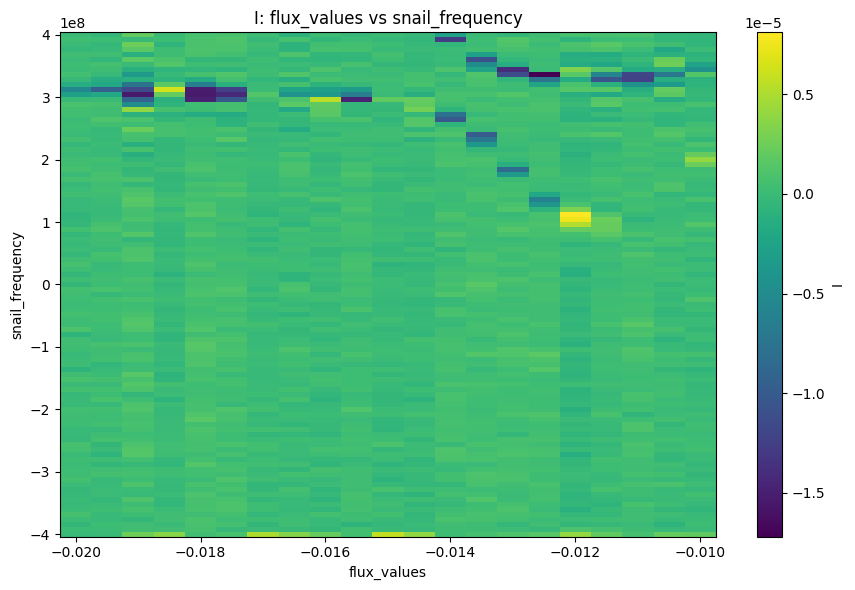

In [5]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================

folder_path = r"C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-05/"

start_time = (11, 52)
end_time   = (12, 23)

# X-axis values
flux_values = [-0.02  , -0.0195, -0.019 , -0.0185, -0.018 , -0.0175, -0.017 , -0.0165,
 -0.016 , -0.0155, -0.015 , -0.0145, -0.014 , -0.0135, -0.013 , -0.0125,
 -0.012 , -0.0115, -0.011 , -0.0105, -0.01  ]#np.linspace(start=-20e-3, stop=5e-3, num=51)
x_values = flux_values
x_label = "flux_values"

file_key = "snail_spec_threetone_cavspec_versus_flux"

# Data channel to plot: "I", "Q", or "MAG"
plot_data = "I"

# Sweep axis key
# None -> automatically use first dataset in file
# Example:
# y_key = "freq_GHz"
# y_key = "flux"
# y_key = "power"
y_key = None

# Show individual traces?
show_individual_plots = False

# Save processed data?
save_npz = True
save_name = "SnailSpec_twotone_sideq_processed.npz"

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = filename.split("-")
        hour = int(parts[0])
        minute = int(parts[1])
        return (hour, minute)
    except:
        return (-1, -1)


def get_filtered_files(folder, start_time, end_time):
    selected = []

    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return selected

    for filename in os.listdir(folder):

        if not filename.endswith(".hdf5"):
            continue

        if file_key not in filename:
            continue

        t = extract_time(filename)

        if start_time <= t <= end_time:
            selected.append(os.path.join(folder, filename))

    selected.sort()
    return selected


# ==========================================================
# LOAD FILES
# ==========================================================

grouped_filenames = get_filtered_files(
    folder_path,
    start_time,
    end_time
)

print(f"Found {len(grouped_filenames)} files")

if len(grouped_filenames) == 0:
    raise ValueError("No files found!")

# ==========================================================
# DISPLAY AVAILABLE KEYS
# ==========================================================

with h5py.File(grouped_filenames[0], "r") as f:

    print("\nAvailable keys:")

    for k in f.keys():
        print("  ", k)

# ==========================================================
# EXTRACT DATA
# ==========================================================

sweep_axis = []

I_2d = []
Q_2d = []
MAG_2d = []

for i, filename in enumerate(grouped_filenames):

    print(f"Loading: {os.path.basename(filename)}")

    with h5py.File(filename, "r") as f:

        # ----------------------------------
        # Choose sweep-axis dataset
        # ----------------------------------

        if y_key is None:
            key = list(f.keys())[0]
        else:
            key = y_key

        y_values = np.array(f[key][()])

        # ----------------------------------
        # Read channels
        # ----------------------------------

        I_values = np.mean(f["I"][()], axis=0)
        I_values -= np.mean(I_values)

        Q_values = np.mean(f["Q"][()], axis=0)
        Q_values -= np.mean(Q_values)

        MAG_values = np.mean(f["Magnitude"][()], axis=0)
        MAG_values -= np.mean(MAG_values)

        # ----------------------------------
        # Store all channels
        # ----------------------------------

        sweep_axis.append(y_values)

        I_2d.append(I_values)
        Q_2d.append(Q_values)
        MAG_2d.append(MAG_values)

        # ----------------------------------
        # Select channel for optional plotting
        # ----------------------------------

        channel_dict = {
            "I": I_values,
            "Q": Q_values,
            "MAG": MAG_values,
        }

        selected_data = channel_dict[plot_data]

        # ----------------------------------
        # Optional individual traces
        # ----------------------------------

        if show_individual_plots:

            plt.figure(figsize=(8, 4))

            plt.plot(y_values, selected_data)

            plt.xlabel(key)
            plt.ylabel(plot_data)

            if i < len(x_values):
                plt.title(f"{plot_data}, {x_label} = {x_values[i]}")
            else:
                plt.title(plot_data)

            plt.grid(True)
            plt.tight_layout()
            plt.show()

# ==========================================================
# CONVERT TO ARRAYS
# ==========================================================

sweep_axis = np.array(sweep_axis)

I_2d = np.array(I_2d)
Q_2d = np.array(Q_2d)
MAG_2d = np.array(MAG_2d)

x_values = np.array(x_values[:len(grouped_filenames)])

channel_dict_2d = {
    "I": I_2d,
    "Q": Q_2d,
    "MAG": MAG_2d,
}

data_2d = channel_dict_2d[plot_data]

print("I shape:", I_2d.shape)
print("Q shape:", Q_2d.shape)
print("MAG shape:", MAG_2d.shape)
print("2D data shape:", data_2d.shape)

# ==========================================================
# SAVE NPZ
# ==========================================================

if save_npz:

    save_path = os.path.join(folder_path, save_name)

    np.savez(
        save_path,
        x_values=x_values,
        y_values=sweep_axis[0],
        sweep_axis=sweep_axis,
        I=I_2d,
        Q=Q_2d,
        MAG=MAG_2d,
        filenames=np.array([os.path.basename(f) for f in grouped_filenames]),
        filepaths=np.array(grouped_filenames),
        x_label=x_label,
        y_key=key,
        file_key=file_key,
    )

    print(f"Saved npz to: {save_path}")

# ==========================================================
# 2D COLORMAP
# ==========================================================

plt.figure(figsize=(9, 6))

plt.pcolormesh(
    x_values,
    sweep_axis[0],
    data_2d.T,
    shading="auto",
    cmap="viridis"
)

plt.xlabel(x_label)
plt.ylabel(key)

plt.title(
    f"{plot_data}: {x_label} vs {key}"
)

plt.colorbar(label=plot_data)

plt.tight_layout()
plt.show()

In [37]:
data = np.load(
    r"C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-04/SnailSpec_twotone_sideq_processed.npz"
)

x_values = data["x_values"]
y_values = data["y_values"]

I_2d = data["I"]
Q_2d = data["Q"]
MAG_2d = data["MAG"]

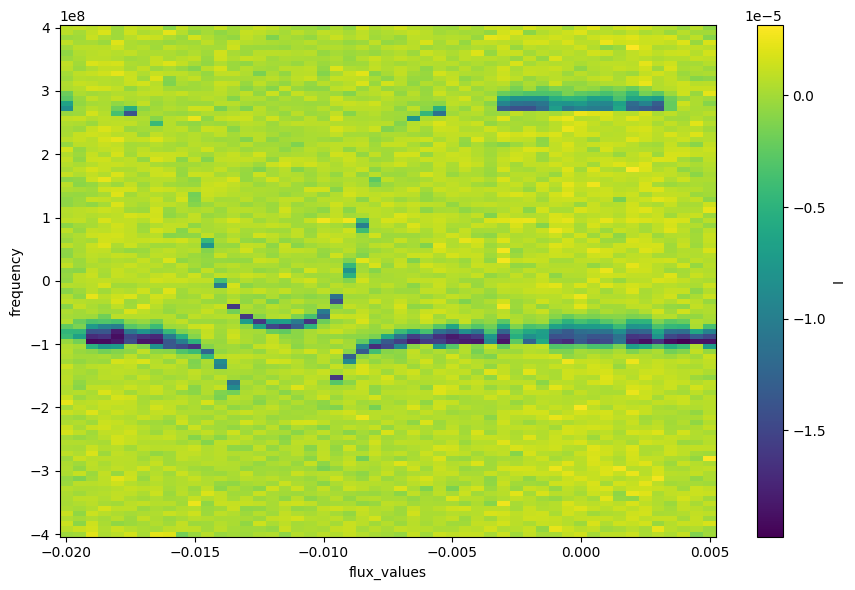

In [38]:
plt.figure(figsize=(9, 6))

plt.pcolormesh(
    x_values,
    y_values,
    I_2d.T,
    shading="auto",
    cmap="viridis"
)

plt.xlabel("flux_values")
plt.ylabel("frequency")
plt.colorbar(label="I")
plt.tight_layout()
plt.show()

## one batch and get min

Flux		Min Frequency	Min Value
--------------------------------------------------
-0.020000	272000000.000000	-0.000008
-0.019500	-88000000.000000	-0.000007
-0.019000	-96000000.000000	-0.000019
-0.018500	-96000000.000000	-0.000019
-0.018000	-88000000.000000	-0.000019
-0.017500	-88000000.000000	-0.000015
-0.017000	-96000000.000000	-0.000018
-0.016500	-96000000.000000	-0.000018
-0.016000	-96000000.000000	-0.000014
-0.015500	-104000000.000000	-0.000015
-0.015000	-104000000.000000	-0.000016
-0.014500	-112000000.000000	-0.000012
-0.014000	-8000000.000000	-0.000010
-0.013500	-40000000.000000	-0.000016
-0.013000	-56000000.000000	-0.000016
-0.012500	-64000000.000000	-0.000016
-0.012000	-72000000.000000	-0.000015
-0.011500	-72000000.000000	-0.000016
-0.011000	-72000000.000000	-0.000013
-0.010500	-64000000.000000	-0.000016
-0.010000	-56000000.000000	-0.000013
-0.009500	-152000000.000000	-0.000016
-0.009000	-120000000.000000	-0.000013
-0.008500	-112000000.000000	-0.000013
-0.008000	-104000000.00000

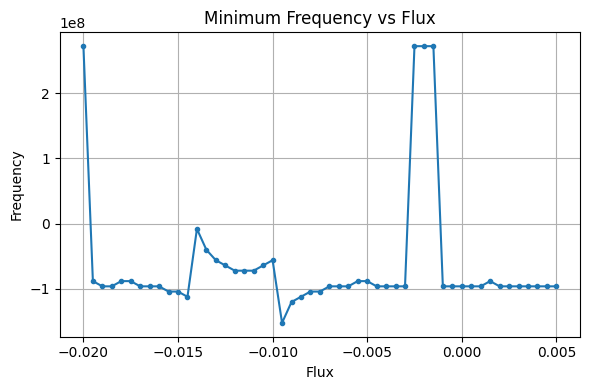

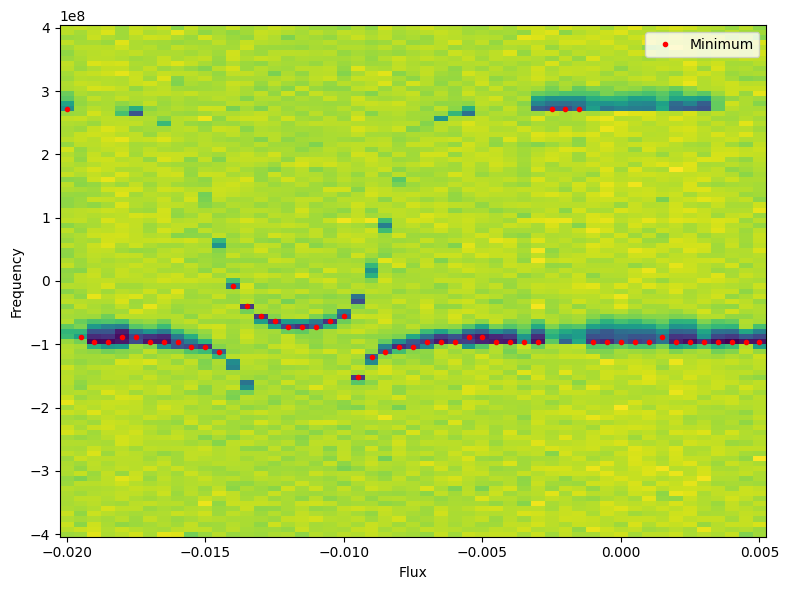

In [62]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load(
    r"C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-04/SnailSpec_twotone_sideq_processed.npz"
)

x_values = data["x_values"]
y_values = data["y_values"]

I_2d = data["I"]
Q_2d = data["Q"]
MAG_2d = data["MAG"]

# Choose which data to analyze
trace = I_2d        # or Q_2d or MAG_2d

# Find minimum of each trace
min_idx = np.argmin(trace, axis=1)

min_freq = y_values[min_idx]
min_value = trace[np.arange(len(x_values)), min_idx]

print("Flux\t\tMin Frequency\tMin Value")
print("-"*50)

for flux, freq, val in zip(x_values, min_freq, min_value):
    print(f"{flux:.6f}\t{freq:.6f}\t{val:.6f}")

# Plot minimum frequency vs flux
plt.figure(figsize=(6,4))
plt.plot(x_values, min_freq, ".-")
plt.xlabel("Flux")
plt.ylabel("Frequency")
plt.title("Minimum Frequency vs Flux")
plt.grid(True)
plt.tight_layout()
plt.show()

# Overlay on the colormap
plt.figure(figsize=(8,6))
plt.pcolormesh(
    x_values,
    y_values,
    trace.T,
    shading="auto",
    cmap="viridis"
)

plt.plot(x_values, min_freq, "r.", ms=6, label="Minimum")
plt.xlabel("Flux")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [63]:
current_A_print = np.array(x_values)
if_freq = np.array(min_freq)

# Select range: -15 mA to -9 mA
mask = (current_A_print >= -15-3) & (current_A_print <= -10e-3)

current_A_print = current_A_print[mask]
if_freq = if_freq[mask]

print("current_A_print")
print(np.array2string(current_A_print, separator=', '))

print("\nif_freq")
print(np.array2string(if_freq, separator=', '))

current_A_print
[-0.02  , -0.0195, -0.019 , -0.0185, -0.018 , -0.0175, -0.017 , -0.0165,
 -0.016 , -0.0155, -0.015 , -0.0145, -0.014 , -0.0135, -0.013 , -0.0125,
 -0.012 , -0.0115, -0.011 , -0.0105, -0.01  ]

if_freq
[ 272000000,  -88000000,  -96000000,  -96000000,  -88000000,  -88000000,
  -96000000,  -96000000,  -96000000, -104000000, -104000000, -112000000,
   -8000000,  -40000000,  -56000000,  -64000000,  -72000000,  -72000000,
  -72000000,  -64000000,  -56000000]


Found 51 files

Available keys:
   snail_frequency
   I
   Q
   Magnitude
Loading: 16-39-41_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading: 16-39-54_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading: 16-40-07_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading: 16-40-20_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading: 16-40-33_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading: 16-40-46_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading: 16-40-59_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading: 16-41-12_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading: 16-41-24_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading: 16-41-37_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading: 16-41-50_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading: 16-42-03_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading: 16-42-16_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading: 16-42-29_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading: 16-42-42_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading: 16-42-55_SnailSpec_twotone_sideq

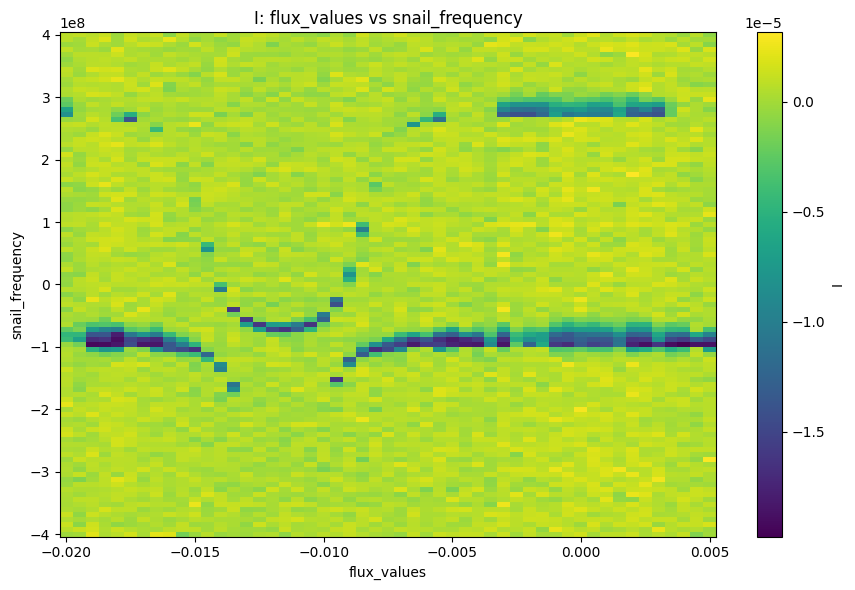

In [29]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================

folder_path = r"C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-04/"

start_time = (16, 39)
end_time   = (16, 50)

# X-axis values (length sweep example)
flux_values = np.linspace(start=-20e-3, stop=5e-3, num=51)#[0:44]
# length = np.array(np.linspace(4, 80_000, 101))
x_values = flux_values
x_label = "flux_values"
file_key = "SnailSpec_twotone_sideq"

# Data channel to plot: "I", "Q", or "MAG"
plot_data = "I"

# Sweep axis key
# None -> automatically use first dataset in file
# Example:
# y_key = "freq_GHz"
# y_key = "flux"
# y_key = "power"
y_key = None

# Show individual traces?
show_individual_plots = False

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = filename.split("-")
        hour = int(parts[0])
        minute = int(parts[1])
        return (hour, minute)
    except:
        return (-1, -1)


def get_filtered_files(folder, start_time, end_time):

    selected = []

    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return selected

    for filename in os.listdir(folder):

        if not filename.endswith(".hdf5"):
            continue

        if file_key not in filename:
            continue

        t = extract_time(filename)

        if start_time <= t <= end_time:
            selected.append(os.path.join(folder, filename))

    selected.sort()

    return selected


# ==========================================================
# LOAD FILES
# ==========================================================

grouped_filenames = get_filtered_files(
    folder_path,
    start_time,
    end_time
)

print(f"Found {len(grouped_filenames)} files")

if len(grouped_filenames) == 0:
    raise ValueError("No files found!")

# ==========================================================
# DISPLAY AVAILABLE KEYS
# ==========================================================

with h5py.File(grouped_filenames[0], "r") as f:

    print("\nAvailable keys:")

    for k in f.keys():
        print("  ", k)

# ==========================================================
# EXTRACT DATA
# ==========================================================

sweep_axis = []
data_2d = []

for i, filename in enumerate(grouped_filenames):

    print(f"Loading: {os.path.basename(filename)}")

    with h5py.File(filename, "r") as f:

        # ----------------------------------
        # Choose sweep-axis dataset
        # ----------------------------------

        if y_key is None:
            key = list(f.keys())[0]
        else:
            key = y_key

        y_values = np.array(f[key][()])

        # ----------------------------------
        # Read channels
        # ----------------------------------

        I_values = np.mean(f["I"][()], axis=0)
        I_values -= np.mean(I_values)

        Q_values = np.mean(f["Q"][()], axis=0)
        Q_values -= np.mean(Q_values)

        MAG_values = np.mean(f["Magnitude"][()], axis=0)
        MAG_values -= np.mean(MAG_values)

        channel_dict = {
            "I": I_values,
            "Q": Q_values,
            "MAG": MAG_values,
        }

        selected_data = channel_dict[plot_data]

        sweep_axis.append(y_values)
        data_2d.append(selected_data)

        # ----------------------------------
        # Optional individual traces
        # ----------------------------------

        if show_individual_plots:

            plt.figure(figsize=(8,4))

            plt.plot(y_values, selected_data)

            plt.xlabel(key)
            plt.ylabel(plot_data)

            if i < len(x_values):
                plt.title(f"{plot_data}, {x_label} = {x_values[i]}")
            else:
                plt.title(plot_data)

            plt.grid(True)
            plt.tight_layout()
            plt.show()

# ==========================================================
# CONVERT TO ARRAYS
# ==========================================================

sweep_axis = np.array(sweep_axis)
data_2d = np.array(data_2d)

x_values = np.array(x_values[:len(grouped_filenames)])

print("2D data shape:", data_2d.shape)

# ==========================================================
# 2D COLORMAP
# ==========================================================

plt.figure(figsize=(9,6))

plt.pcolormesh(
    x_values,
    sweep_axis[0],
    data_2d.T,
    shading="auto",
    cmap="viridis"
)

plt.xlabel(x_label)
plt.ylabel(key)

plt.title(
    f"{plot_data}: {x_label} vs {key}"
)

plt.colorbar(label=plot_data)

plt.tight_layout()
plt.show()

Processing 37 total files...


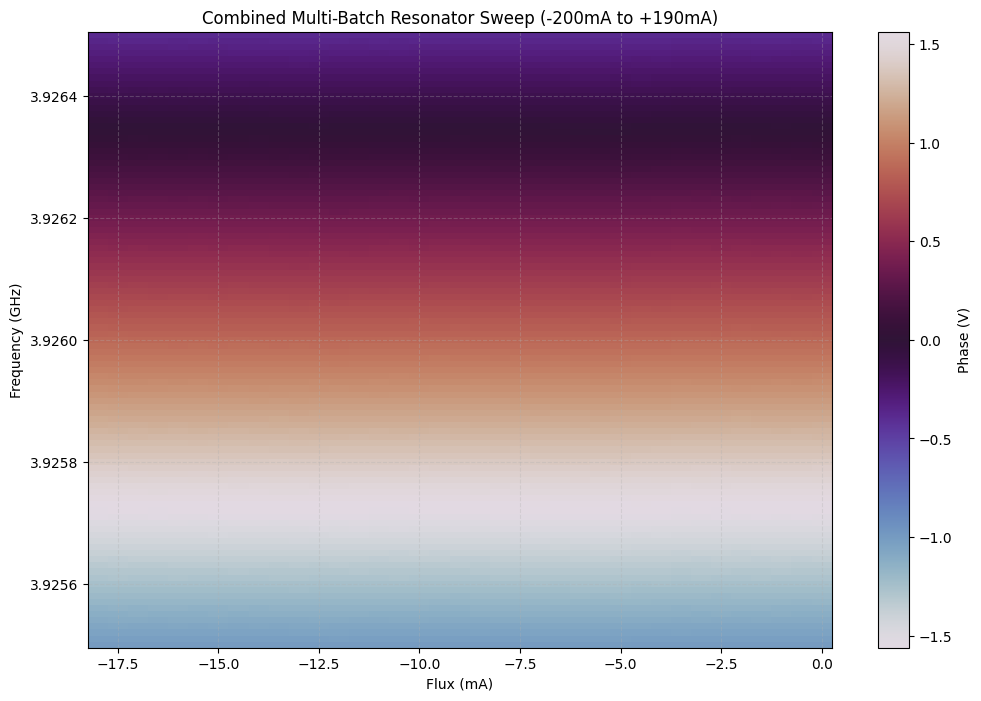

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

# --- Define all batches in a list for easy management ---
batches = [
    {
        "folder": "C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-06-25/",
        "time": ((18, 34), (19, 19)),
        "flux": np.linspace(start=-18e-3, stop=18e-3, num=73) #np.arange(0e-3, 100e-3 + 10e-3, 10e-3)
        # flux_values = np.linspace(start=-10e-3, stop=10e-3, num=21)
    },
    # {
    #     "folder": "C:/Users/qcrew/Documents/eunice/data/2026-02-25/",
    #     "time": ((16, 35), (16, 40)),
    #     "flux": np.arange(-100e-3, -200e-3 - 10e-3, -10e-3)
    # },
    # {
    #     "folder": "C:/Users/qcrew/Documents/eunice/data/2026-02-25/",
    #     "time": ((16, 49), (17, 2)),
    #     "flux": np.arange(0e-3, 190e-3 + 5e-3, 5e-3)
    # }
]

def get_filtered_files(folder, start_t, end_t):
    if not os.path.exists(folder):
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) 
             if f.endswith(".hdf5") and "RRSpec" in f]
    
    def extract_t(fname):
        parts = os.path.basename(fname).split("-")
        return (int(parts[0]), int(parts[1]))

    # Filter and Sort by time to match the flux sequence recorded
    filtered = [f for f in files if end_t >= extract_t(f) >= start_t]
    filtered.sort() 
    return filtered

# 1. Collect all data pairs (Flux, Filename) across all batches
all_data_pairs = []

for b in batches:
    files = get_filtered_files(b["folder"], b["time"][0], b["time"][1])
    for i, f in enumerate(files):
        if i < len(b["flux"]):
            all_data_pairs.append((b["flux"][i], f))

# 2. Sort by Flux so the Y-axis is monotonic (e.g., -200mA up to +190mA)
all_data_pairs.sort(key=lambda x: x[0])

# 3. Load Magnitude data
final_flux_axis = []
final_mag_matrix = []
freq_axis = None

print(f"Processing {len(all_data_pairs)} total files...")

for flux, path in all_data_pairs:
    try:
        with h5py.File(path, "r") as f:
            if freq_axis is None:
                lo = 3.925e9+50e6 #3.868364e9+50e6-1.443e6 #f["instruments/lo_rr"].attrs["frequency"] if "instruments/lo_rr" in f else 0
                freq_axis = (lo + f["resonator_frequency"][()]) / 1e9 # GHz
            
            I = np.mean(f["I"][()], axis=0)
            Q = np.mean(f["Q"][()], axis=0)
            phase = np.arctan(Q/I)
            mag = np.mean(f["Magnitude"][()], axis=0)
            final_mag_matrix.append(phase)
            final_flux_axis.append(flux * 1e3) # mA
    except Exception as e:
        print(f"Skipping {path} due to error: {e}")

# 4. Generate the Heatmap
if final_mag_matrix:
    plt.figure(figsize=(12, 8))
    X, Y = np.meshgrid(freq_axis, final_flux_axis)
    Z = np.array(final_mag_matrix)

    # 'magma' or 'viridis' work well for spectroscopy
    mesh = plt.pcolormesh(Y.T, X.T, Z.T, shading='auto', cmap='twilight')
    
    plt.colorbar(mesh, label='Phase (V)')
    plt.ylabel('Frequency (GHz)')
    plt.xlabel('Flux (mA)')
    plt.title('Combined Multi-Batch Resonator Sweep (-200mA to +190mA)')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.show()
else:
    print("No data found to plot!")

Processing 10 total files...


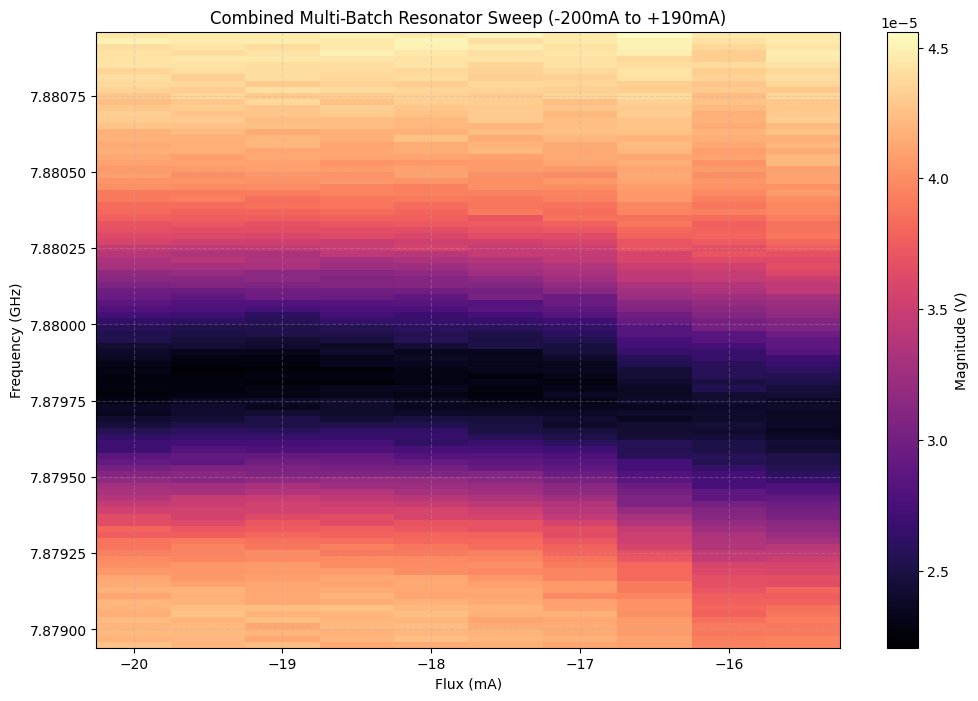

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

# --- Define all batches in a list for easy management ---
batches = [
    {
        "folder": "C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-06-10/",
        "time": ((18, 45), (18, 59)),
        "flux": np.linspace(start=-20e-3, stop=0e-3, num=41)[0:10] #np.arange(0e-3, 100e-3 + 10e-3, 10e-3)
        # flux_values = np.linspace(start=-10e-3, stop=10e-3, num=21)
    },
    # {
    #     "folder": "C:/Users/qcrew/Documents/eunice/data/2026-02-25/",
    #     "time": ((16, 35), (16, 40)),
    #     "flux": np.arange(-100e-3, -200e-3 - 10e-3, -10e-3)
    # },
    # {
    #     "folder": "C:/Users/qcrew/Documents/eunice/data/2026-02-25/",
    #     "time": ((16, 49), (17, 2)),
    #     "flux": np.arange(0e-3, 190e-3 + 5e-3, 5e-3)
    # }
]

def get_filtered_files(folder, start_t, end_t):
    if not os.path.exists(folder):
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) 
             if f.endswith(".hdf5") and "RRSpec" in f]
    
    def extract_t(fname):
        parts = os.path.basename(fname).split("-")
        return (int(parts[0]), int(parts[1]))

    # Filter and Sort by time to match the flux sequence recorded
    filtered = [f for f in files if end_t >= extract_t(f) >= start_t]
    filtered.sort() 
    return filtered

# 1. Collect all data pairs (Flux, Filename) across all batches
all_data_pairs = []

for b in batches:
    files = get_filtered_files(b["folder"], b["time"][0], b["time"][1])
    for i, f in enumerate(files):
        if i < len(b["flux"]):
            all_data_pairs.append((b["flux"][i], f))

# 2. Sort by Flux so the Y-axis is monotonic (e.g., -200mA up to +190mA)
all_data_pairs.sort(key=lambda x: x[0])

# 3. Load Magnitude data
final_flux_axis = []
final_mag_matrix = []
freq_axis = None

print(f"Processing {len(all_data_pairs)} total files...")

for flux, path in all_data_pairs:
    try:
        with h5py.File(path, "r") as f:
            if freq_axis is None:
                lo = 7.88e9+32e6+21e6-0.3e6-2e6-0.6e6-0.15e6 #3.868364e9+50e6-1.443e6 #f["instruments/lo_rr"].attrs["frequency"] if "instruments/lo_rr" in f else 0
                freq_axis = (lo + f["resonator_frequency"][()]) / 1e9 # GHz
            
            mag = np.mean(f["Magnitude"][()], axis=0)
            final_mag_matrix.append(mag)
            final_flux_axis.append(flux * 1e3) # mA
    except Exception as e:
        print(f"Skipping {path} due to error: {e}")

# 4. Generate the Heatmap
if final_mag_matrix:
    plt.figure(figsize=(12, 8))
    X, Y = np.meshgrid(freq_axis, final_flux_axis)
    Z = np.array(final_mag_matrix)

    # 'magma' or 'viridis' work well for spectroscopy
    mesh = plt.pcolormesh(Y.T, X.T, Z.T, shading='auto', cmap='magma')
    
    plt.colorbar(mesh, label='Magnitude (V)')
    plt.ylabel('Frequency (GHz)')
    plt.xlabel('Flux (mA)')
    plt.title('Combined Multi-Batch Resonator Sweep (-200mA to +190mA)')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.show()
else:
    print("No data found to plot!")

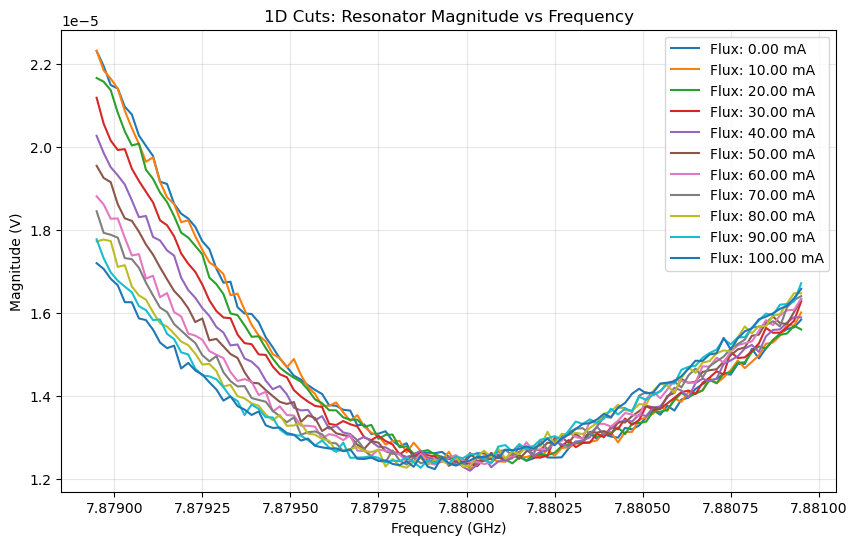

In [6]:
# --- 5. Generate 1D Cuts ---
if final_mag_matrix:
    # Choose the flux values (mA) you want to see a 1D cut for
    # Example: the middle flux, or specific values like 0mA or 50mA
    target_fluxes = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100] # mA
    
    plt.figure(figsize=(10, 6))
    
    for target in target_fluxes:
        # Find the index of the flux value closest to our target
        idx = (np.abs(np.array(final_flux_axis) - target)).argmin()
        actual_flux = final_flux_axis[idx]
        
        # Plot Frequency vs Magnitude for that specific flux row
        plt.plot(freq_axis, final_mag_matrix[idx], label=f"Flux: {actual_flux:.2f} mA")

    plt.xlabel('Frequency (GHz)')
    plt.ylabel('Magnitude (V)')
    plt.title('1D Cuts: Resonator Magnitude vs Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Processing 22 total files...


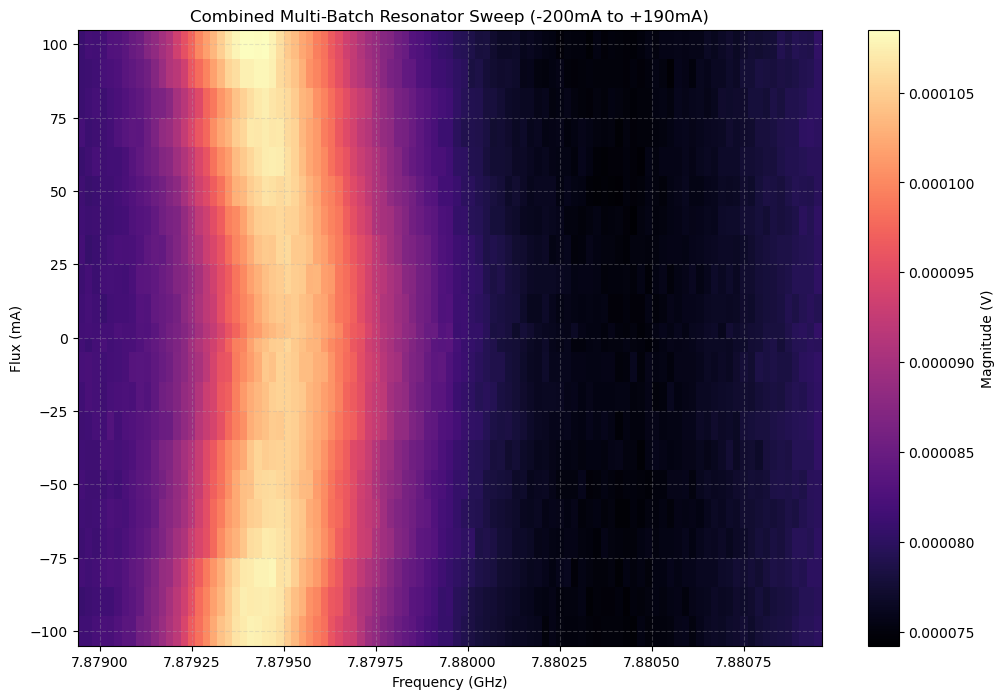

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

# --- Define all batches in a list for easy management ---
batches = [
    {
        "folder": "C:/Users/qcrew2/Documents/Candace/eunice/data/2026-03-12/",
        "time": ((21, 4), (21, 10)),
        "flux": np.arange(0e-3, 100e-3 + 10e-3, 10e-3)
    },
    {
        "folder": "C:/Users/qcrew2/Documents/Candace/eunice/data/2026-03-12/",
        "time": ((21, 14), (21, 20)),
        "flux": np.arange(0e-3, -100e-3 - 10e-3, -10e-3)
    },
    # {
    #     "folder": "C:/Users/qcrew/Documents/eunice/data/2026-02-25/",
    #     "time": ((16, 49), (17, 2)),
    #     "flux": np.arange(0e-3, 190e-3 + 5e-3, 5e-3)
    # }
]

def get_filtered_files(folder, start_t, end_t):
    if not os.path.exists(folder):
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) 
             if f.endswith(".hdf5") and "RRSpec" in f]
    
    def extract_t(fname):
        parts = os.path.basename(fname).split("-")
        return (int(parts[0]), int(parts[1]))

    # Filter and Sort by time to match the flux sequence recorded
    filtered = [f for f in files if end_t >= extract_t(f) >= start_t]
    filtered.sort() 
    return filtered

# 1. Collect all data pairs (Flux, Filename) across all batches
all_data_pairs = []

for b in batches:
    files = get_filtered_files(b["folder"], b["time"][0], b["time"][1])
    for i, f in enumerate(files):
        if i < len(b["flux"]):
            all_data_pairs.append((b["flux"][i], f))

# 2. Sort by Flux so the Y-axis is monotonic (e.g., -200mA up to +190mA)
all_data_pairs.sort(key=lambda x: x[0])

# 3. Load Magnitude data
final_flux_axis = []
final_mag_matrix = []
freq_axis = None

print(f"Processing {len(all_data_pairs)} total files...")

for flux, path in all_data_pairs:
    try:
        with h5py.File(path, "r") as f:
            if freq_axis is None:
                lo = 7.88e9+32e6+21e6-0.3e6-2e6-0.6e6-0.15e6 #3.868364e9+50e6-1.443e6 #f["instruments/lo_rr"].attrs["frequency"] if "instruments/lo_rr" in f else 0
                freq_axis = (lo + f["resonator_frequency"][()]) / 1e9 # GHz
            
            mag = np.mean(f["Magnitude"][()], axis=0)
            final_mag_matrix.append(mag)
            final_flux_axis.append(flux * 1e3) # mA
    except Exception as e:
        print(f"Skipping {path} due to error: {e}")

# 4. Generate the Heatmap
if final_mag_matrix:
    plt.figure(figsize=(12, 8))
    X, Y = np.meshgrid(freq_axis, final_flux_axis)
    Z = np.array(final_mag_matrix)

    # 'magma' or 'viridis' work well for spectroscopy
    mesh = plt.pcolormesh(X, Y, Z, shading='auto', cmap='magma')
    
    plt.colorbar(mesh, label='Magnitude (V)')
    plt.xlabel('Frequency (GHz)')
    plt.ylabel('Flux (mA)')
    plt.title('Combined Multi-Batch Resonator Sweep (-200mA to +190mA)')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.show()
else:
    print("No data found to plot!")

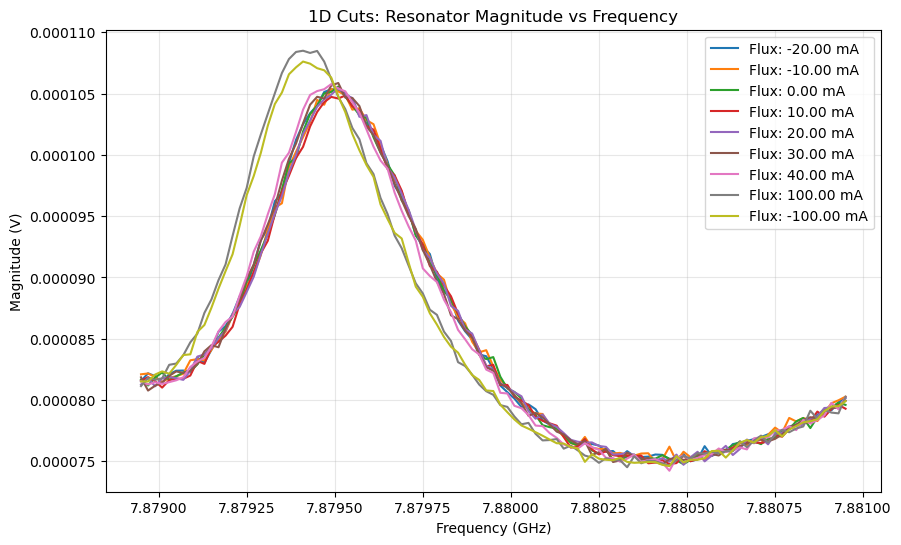

In [12]:
# --- 5. Generate 1D Cuts ---
if final_mag_matrix:
    # Choose the flux values (mA) you want to see a 1D cut for
    # Example: the middle flux, or specific values like 0mA or 50mA
    target_fluxes = [-20, -10, 0, 10, 20, 30, 40, 100,-100]#np.arange(-100, 100,10) #[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100] # mA
    
    plt.figure(figsize=(10, 6))
    
    for target in target_fluxes:
        # Find the index of the flux value closest to our target
        idx = (np.abs(np.array(final_flux_axis) - target)).argmin()
        actual_flux = final_flux_axis[idx]
        
        # Plot Frequency vs Magnitude for that specific flux row
        plt.plot(freq_axis, final_mag_matrix[idx], label=f"Flux: {actual_flux:.2f} mA")

    plt.xlabel('Frequency (GHz)')
    plt.ylabel('Magnitude (V)')
    plt.title('1D Cuts: Resonator Magnitude vs Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Processing 32 total files...


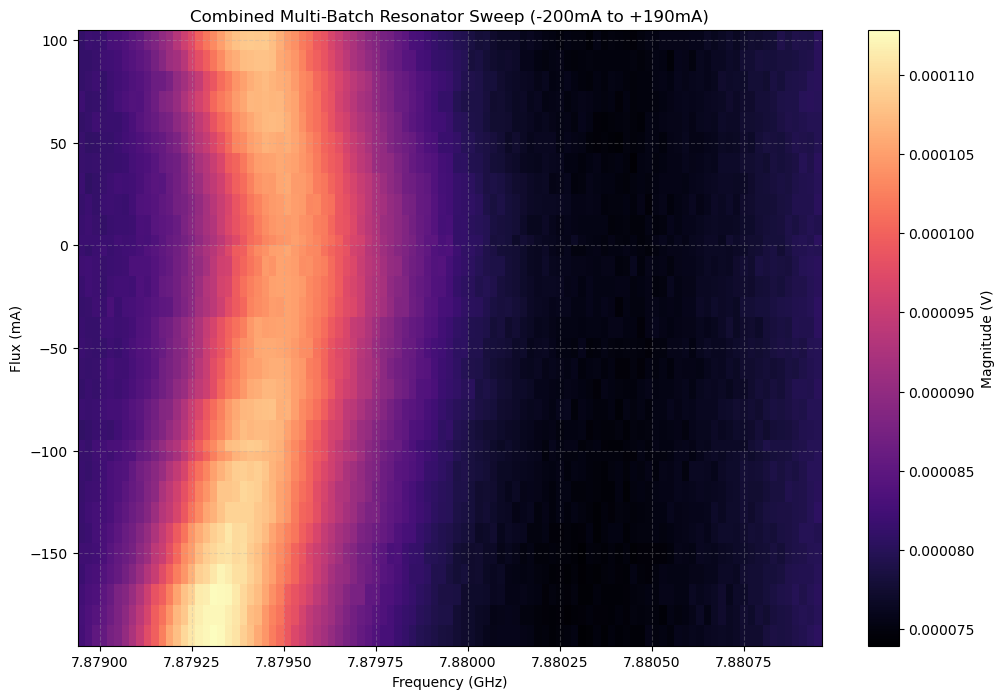

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

# --- Define all batches in a list for easy management ---
batches = [
    {
        "folder": "C:/Users/qcrew2/Documents/Candace/eunice/data/2026-03-12/",
        "time": ((21, 4), (21, 10)),
        "flux": np.arange(0e-3, 100e-3 + 10e-3, 10e-3)
    },
    {
        "folder": "C:/Users/qcrew2/Documents/Candace/eunice/data/2026-03-12/",
        "time": ((21, 14), (21, 20)),
        "flux": np.arange(0e-3, -100e-3 - 10e-3, -10e-3)
    },
        {
        "folder": "C:/Users/qcrew2/Documents/Candace/eunice/data/2026-03-12/",
        "time": ((21, 29), (21, 35)),
        "flux": np.arange(-100e-3, -190e-3 - 10e-3, -10e-3)
    },
    # {
    #     "folder": "C:/Users/qcrew/Documents/eunice/data/2026-02-25/",
    #     "time": ((16, 35), (16, 40)),
    #     "flux": np.arange(-100e-3, -200e-3 - 10e-3, -10e-3)
    # },
    # {
    #     "folder": "C:/Users/qcrew/Documents/eunice/data/2026-02-25/",
    #     "time": ((16, 49), (17, 2)),
    #     "flux": np.arange(0e-3, 190e-3 + 5e-3, 5e-3)
    # }
]

def get_filtered_files(folder, start_t, end_t):
    if not os.path.exists(folder):
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) 
             if f.endswith(".hdf5") and "RRSpec" in f]
    
    def extract_t(fname):
        parts = os.path.basename(fname).split("-")
        return (int(parts[0]), int(parts[1]))

    # Filter and Sort by time to match the flux sequence recorded
    filtered = [f for f in files if end_t >= extract_t(f) >= start_t]
    filtered.sort() 
    return filtered

# 1. Collect all data pairs (Flux, Filename) across all batches
all_data_pairs = []

for b in batches:
    files = get_filtered_files(b["folder"], b["time"][0], b["time"][1])
    for i, f in enumerate(files):
        if i < len(b["flux"]):
            all_data_pairs.append((b["flux"][i], f))

# 2. Sort by Flux so the Y-axis is monotonic (e.g., -200mA up to +190mA)
all_data_pairs.sort(key=lambda x: x[0])

# 3. Load Magnitude data
final_flux_axis = []
final_mag_matrix = []
freq_axis = None

print(f"Processing {len(all_data_pairs)} total files...")

for flux, path in all_data_pairs:
    try:
        with h5py.File(path, "r") as f:
            if freq_axis is None:
                lo = 7.88e9+32e6+21e6-0.3e6-2e6-0.6e6-0.15e6 #3.868364e9+50e6-1.443e6 #f["instruments/lo_rr"].attrs["frequency"] if "instruments/lo_rr" in f else 0
                freq_axis = (lo + f["resonator_frequency"][()]) / 1e9 # GHz
            
            mag = np.mean(f["Magnitude"][()], axis=0)
            final_mag_matrix.append(mag)
            final_flux_axis.append(flux * 1e3) # mA
    except Exception as e:
        print(f"Skipping {path} due to error: {e}")

# 4. Generate the Heatmap
if final_mag_matrix:
    plt.figure(figsize=(12, 8))
    X, Y = np.meshgrid(freq_axis, final_flux_axis)
    Z = np.array(final_mag_matrix)

    # 'magma' or 'viridis' work well for spectroscopy
    mesh = plt.pcolormesh(X, Y, Z, shading='auto', cmap='magma')
    
    plt.colorbar(mesh, label='Magnitude (V)')
    plt.xlabel('Frequency (GHz)')
    plt.ylabel('Flux (mA)')
    plt.title('Combined Multi-Batch Resonator Sweep (-200mA to +190mA)')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.show()
else:
    print("No data found to plot!")

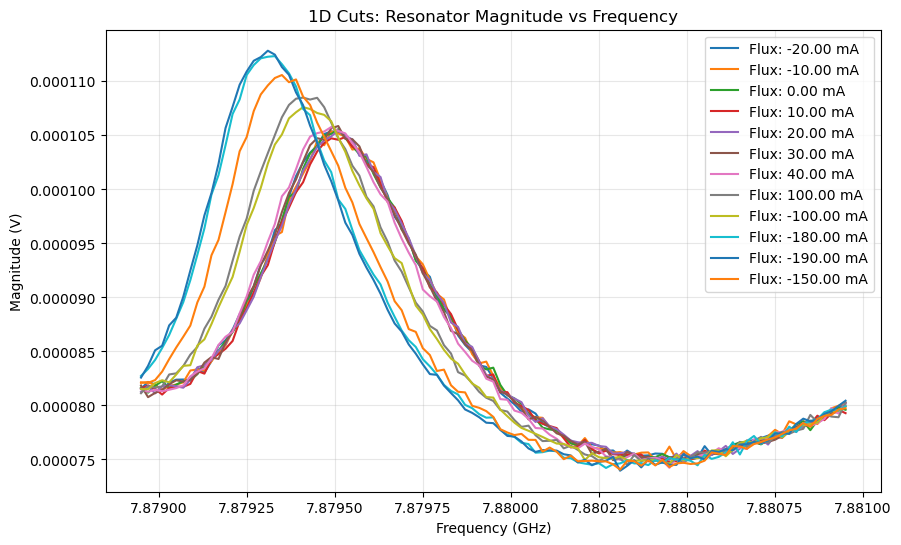

In [17]:
# --- 5. Generate 1D Cuts ---
if final_mag_matrix:
    # Choose the flux values (mA) you want to see a 1D cut for
    # Example: the middle flux, or specific values like 0mA or 50mA
    target_fluxes = [-20, -10, 0, 10, 20, 30, 40, 100,-100, -180,-190, -150]#np.arange(-100, 100,10) #[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100] # mA
    
    plt.figure(figsize=(10, 6))
    
    for target in target_fluxes:
        # Find the index of the flux value closest to our target
        idx = (np.abs(np.array(final_flux_axis) - target)).argmin()
        actual_flux = final_flux_axis[idx]
        
        # Plot Frequency vs Magnitude for that specific flux row
        plt.plot(freq_axis, final_mag_matrix[idx], label=f"Flux: {actual_flux:.2f} mA")

    plt.xlabel('Frequency (GHz)')
    plt.ylabel('Magnitude (V)')
    plt.title('1D Cuts: Resonator Magnitude vs Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [19]:
# Define the filename
save_path = "combined_flux_sweep_20260312_SNAILRM_rr_R.npz"

# Save arrays
# We use keyword arguments so we can load them back easily by name
np.savez(
    save_path, 
    frequency_ghz=freq_axis, 
    flux_ma=np.array(final_flux_axis), 
    magnitude=np.array(final_mag_matrix)
)

print(f"Data successfully saved to {save_path}")

Data successfully saved to combined_flux_sweep_20260312_SNAILRM_rr_R.npz


Number of files selected: 11


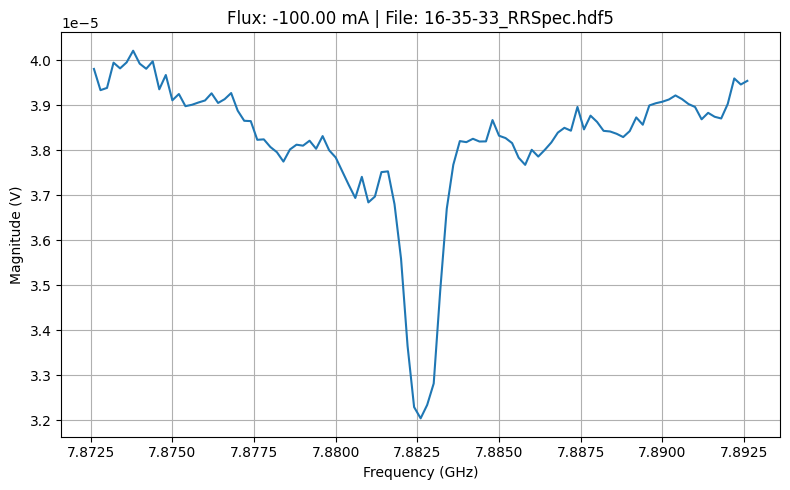

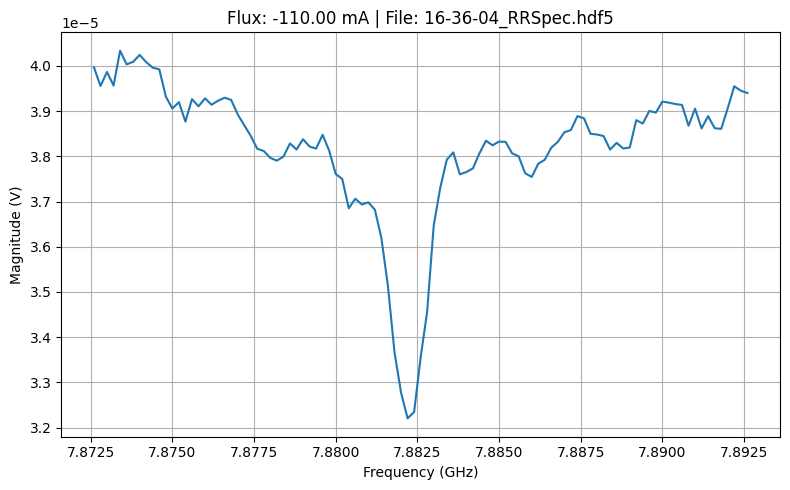

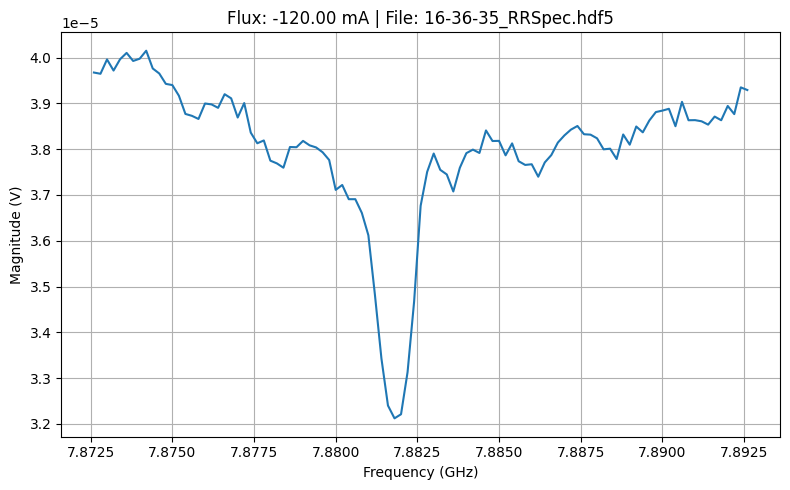

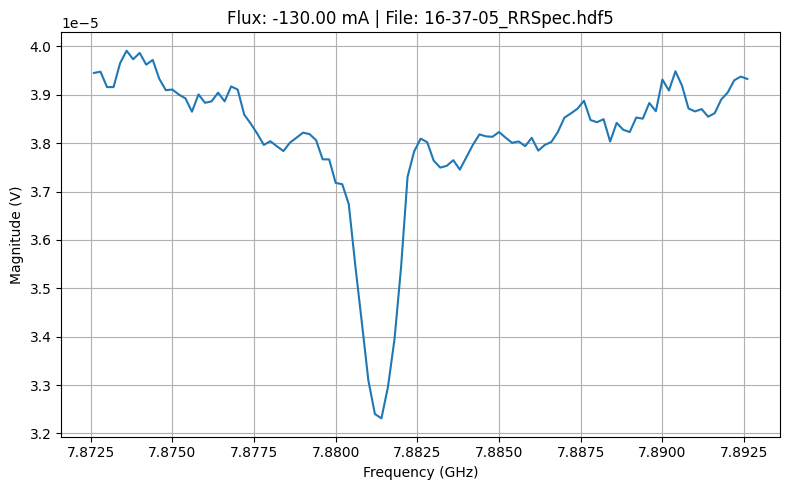

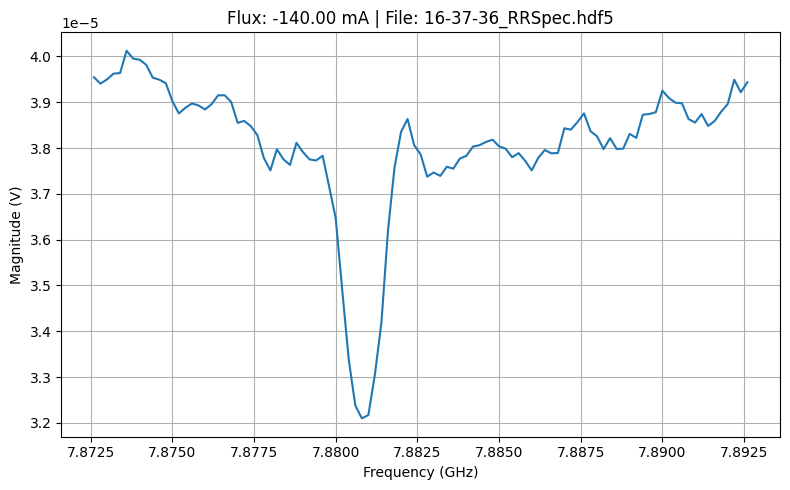

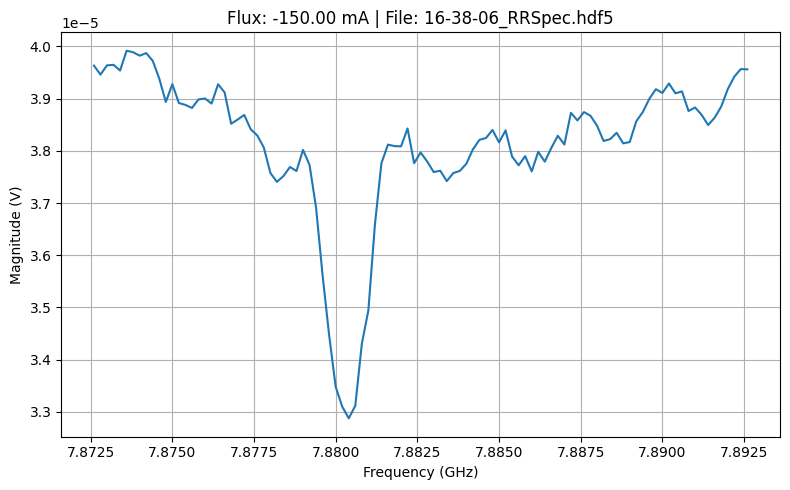

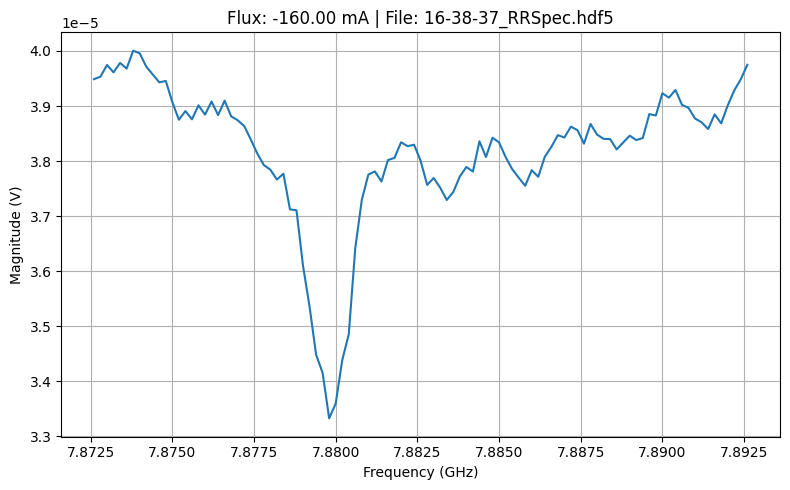

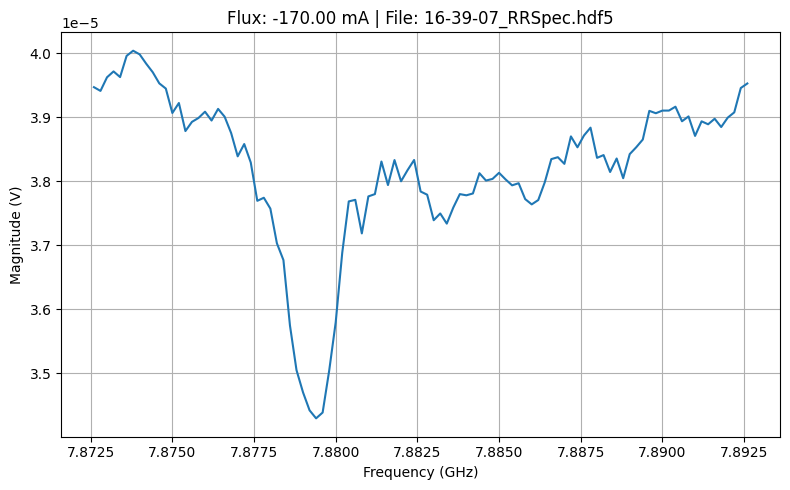

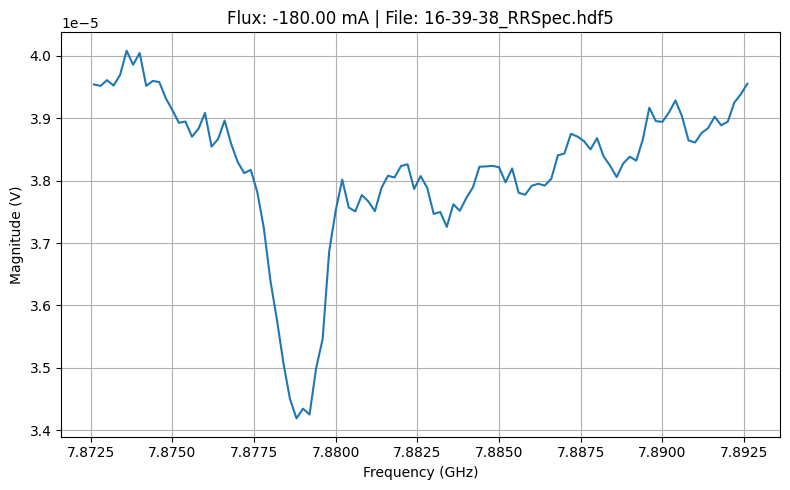

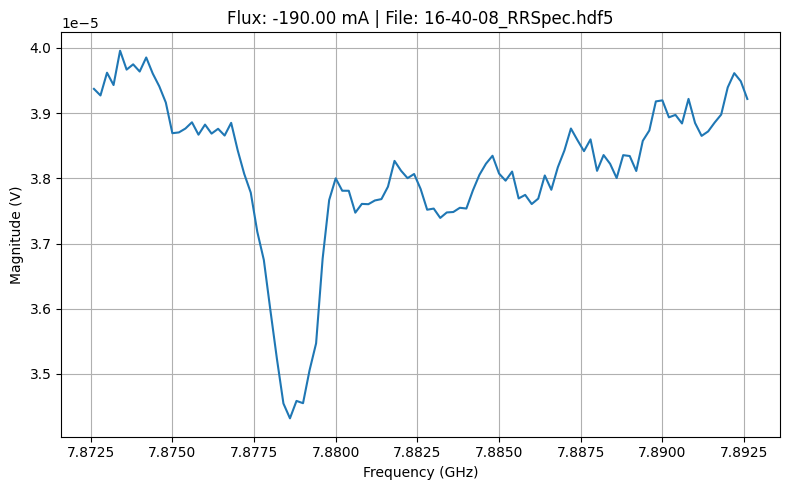

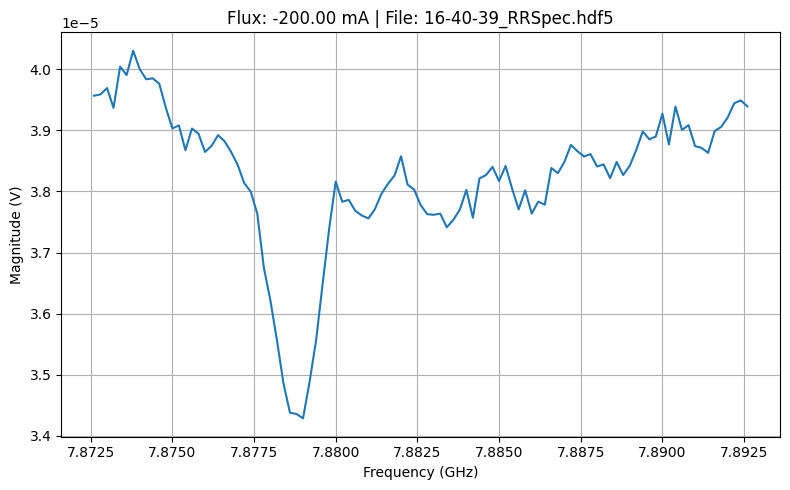

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

# Define folder paths
# _folder_0 = "C:/Users/qcrew/Documents/eunice/data/2026-02-25/"
# filter_time_0 = (16, 15)
# filter_time_0_end = (16, 21)
_folder_0 = "C:/Users/qcrew/Documents/eunice/data/2026-02-25/"
filter_time_0 = (16, 35)
filter_time_0_end = (16, 40)

def extract_time(filename):
    """Extracts (hour, minute) from the filename."""
    try:
        parts = filename.split("-")
        hour, minute = int(parts[0]), int(parts[1])
        return hour, minute
    except (ValueError, IndexError):
        return (-1, -1)

def process_folder(folder_path, start_t, end_t):
    """Processes files in the folder and returns filtered full paths."""
    local_filenames = []
    if not os.path.exists(folder_path):
        print(f"Error: Folder '{folder_path}' does not exist!")
        return local_filenames

    for _filename in os.listdir(folder_path):
        if _filename.endswith(".hdf5") and "RRSpec" in _filename:
            time = extract_time(_filename)
            if time != (-1, -1) and end_t >= time >= start_t:
                local_filenames.append(os.path.join(folder_path, _filename))
    
    # Sort filenames to ensure they match the order of your flux_points
    local_filenames.sort()
    return local_filenames

# Process folder
grouped_filenames = process_folder(_folder_0, filter_time_0, filter_time_0_end)
print(f"Number of files selected: {len(grouped_filenames)}")

# Define Flux Range
# flux_start, flux_end, flux_step = -100e-3, 0e-3, 5e-3
# flux_points = np.arange(flux_start, flux_end + flux_step, flux_step)

flux_start = -100e-3
flux_end = -200e-3
flux_step = -10e-3
flux_points = np.arange(flux_start, flux_end+flux_step, flux_step)
freqs, mag_data = [], []

for index, filename in enumerate(grouped_filenames):
    if index >= len(flux_points):
        print("Warning: More files found than flux points defined.")
        break

    with h5py.File(filename, "r") as f:
        # Extract data
        freqs_values = f["resonator_frequency"][()]
        # Averaging over the first axis (assuming pulse/repetition axis)
        MAG_values = np.mean(f["Magnitude"][()], axis=0) 
        
        # Attempt to get lo_freq from attributes if not defined globally
        # Adjust the key path based on your specific HDF5 structure
        lo_freq = 7.88e9+32e6+21e6-0.3e6+0.1e6-0.3e6+0.1e6 #f["instruments/lo_rr"].attrs["frequency"] if "instruments/lo_rr" in f else 0
        
        full_freqs = lo_freq + freqs_values

        # Store data
        freqs.append(full_freqs)
        mag_data.append(MAG_values)

        # Plotting
        plt.figure(figsize=(8, 5))
        plt.plot(full_freqs / 1e9, MAG_values, label='Magnitude') # Freq in GHz for readability
        plt.xlabel('Frequency (GHz)')
        plt.ylabel('Magnitude (V)')
        plt.title(f'Flux: {flux_points[index]*1e3:.2f} mA | File: {os.path.basename(filename)}')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

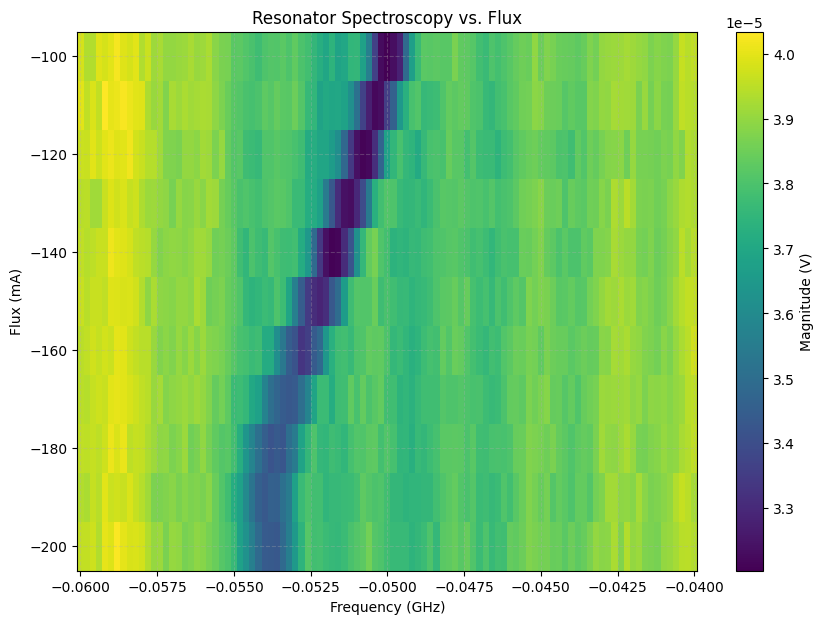

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

# ... (Include your extract_time and process_folder functions here) ...

# 1. Collect Data into lists
all_mags = []
selected_flux = []

for index, filename in enumerate(grouped_filenames):
    if index >= len(flux_points): break
    
    with h5py.File(filename, "r") as f:
        # Get frequency once (assuming it's the same for all files)
        if index == 0:
            lo_freq = f["instruments/lo_rr"].attrs["frequency"] if "instruments/lo_rr" in f else 0
            freq_axis = (lo_freq + f["resonator_frequency"][()]) / 1e9  # Convert to GHz
        
        mag_slice = np.mean(f["Magnitude"][()], axis=0)
        all_mags.append(mag_slice)
        selected_flux.append(flux_points[index] * 1e3) # Convert to mA for plotting

# 2. Convert to 2D numpy array (Rows: Flux, Columns: Frequency)
Z = np.array(all_mags)
X, Y = np.meshgrid(freq_axis, selected_flux)

# 3. Plotting
plt.figure(figsize=(10, 7))
# 'shading="nearest"' or "auto" ensures the grid aligns with your data points
mesh = plt.pcolormesh(X, Y, Z, shading='auto', cmap='viridis')

# Add a colorbar to show magnitude scale
cbar = plt.colorbar(mesh)
cbar.set_label('Magnitude (V)')

plt.xlabel('Frequency (GHz)')
plt.ylabel('Flux (mA)')
plt.title('Resonator Spectroscopy vs. Flux')
plt.grid(True, alpha=0.3, linestyle='--')

plt.show()

## 2D PLOT 

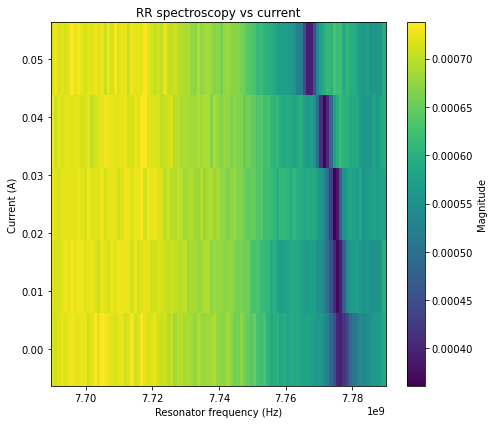

In [5]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt

freqs = None
currents = []
mag_2d = []
phase_2d = []

for filename in grouped_filenames:
    with h5py.File(filename, "r") as f:
        freqs_values = f["resonator_frequency"][()]      # (N_freq,)
        MAG_values   = np.mean(f["Magnitude"][()], axis=0)
        PHASE_values = np.mean(f["Phase"][()], axis=0)
        current      = f["instruments/yoko2"].attrs["current"]
        freqs_values = lo_freq + freqs_values
        if freqs is None:
            freqs = freqs_values
        else:
            # safety check: same frequency grid
            if not np.allclose(freqs, freqs_values):
                raise ValueError("Frequency grids do not match!")

        currents.append(current)
        mag_2d.append(MAG_values)
        phase_2d.append(PHASE_values)
currents = np.array(currents)
mag_2d   = np.array(mag_2d)
phase_2d = np.array(phase_2d)

# sort by current
order = np.argsort(currents)
currents = currents[order]
mag_2d   = mag_2d[order]
phase_2d = phase_2d[order]

plt.figure(figsize=(7, 6))

plt.pcolormesh(
    freqs,
    currents,
    mag_2d,
    shading="auto",
    cmap="viridis"
)

plt.xlabel("Resonator frequency (Hz)")
plt.ylabel("Current (A)")
plt.title("RR spectroscopy vs current")
plt.colorbar(label="Magnitude")

plt.tight_layout()
plt.show()


In [5]:
    # Save data as NPZ
min_current = np.min(currents)
max_current = np.max(currents)
save_name = f"20260210_siderm_rr_flux_sweep{min_current}to{max_current}_2.npz"
np.savez(
save_name,
freq_GHz=freqs,
current_uA=currents,
y_amp_dBfit=mag_2d,
)
print(f"Saved data to {save_name}")

Saved data to 20260210_siderm_rr_flux_sweep-0.15to0.15_2.npz


In [7]:
freqs.shape

(101,)

In [8]:
currents.shape

(31,)

In [9]:
mag_2d.shape

(31, 101)